# Unified temporal robustness analysis

This report combines the visual temporal analysis of the legacy notebook with the leakage-safe family, matching, semantic, and cohort estimands of the current temporal comparison. It reads one explicitly pinned immutable parent and writes only a content-addressed derived enrichment.

In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from artifact_storage import read_artifact
from temporal_unified_analysis import (
    UnifiedAnalysisConfig, normalize_first_finite,
    validate_completed_parent,
)
from temporal_unified_enrichment import load_enrichment
from temporal_cri import load_cri_analysis

# All analysis choices are intentionally centralized here.
ARTIFACT_ROOT = Path('stats/temporal_robustness')
PARENT_HASH = '5fd57eb7b61700cda81e'
COSINE_THRESHOLD = 0.60
OVERLAP_THRESHOLD = 0.70
OVERLAP_PERCENTILE = 70
RECURRENCE_MIN = 0.50  # strict > comparison
ELIGIBILITY_TARGET = 0.50
ELIGIBILITY_MINIMUM_T0_ACTIVE = 10
ACTIVATION_TARGETS = (0.10, 0.30, 0.50)  # P90, P70, P50; never pooled
COHORTS = ('all_comer', 'pipeline_unseen')
TCAV_REPETITIONS = 15
TCAV_FDR_ALPHA = 0.05
TCAV_NEUTRAL_BAND = (0.40, 0.60)
BOOTSTRAP_REPETITIONS = 1000
BOOTSTRAP_SEED = 42

CONFIG = UnifiedAnalysisConfig(
    parent_hash=PARENT_HASH, cosine_threshold=COSINE_THRESHOLD,
    overlap_threshold=OVERLAP_THRESHOLD, overlap_percentile=OVERLAP_PERCENTILE,
    recurrence_min=RECURRENCE_MIN,
    eligibility_activation_target=ELIGIBILITY_TARGET,
    eligibility_minimum_t0_active=ELIGIBILITY_MINIMUM_T0_ACTIVE,
    activation_targets=ACTIVATION_TARGETS, cohorts=COHORTS,
    tcav_repetitions=TCAV_REPETITIONS, tcav_fdr_alpha=TCAV_FDR_ALPHA,
    tcav_neutral_lower=TCAV_NEUTRAL_BAND[0],
    tcav_neutral_upper=TCAV_NEUTRAL_BAND[1],
    bootstrap_repetitions=BOOTSTRAP_REPETITIONS, bootstrap_seed=BOOTSTRAP_SEED,
)
TARGET_LABEL = {0.10: 'P90', 0.30: 'P70', 0.50: 'P50'}
VIEW_LABEL = {'cosine_qualified': 'Cosine-qualified', 'intersection': 'Consensus intersection'}
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

### Factor-level TCAV scores

This audit table shows the actual TCAV result for every evaluated member factor, including factors that do not pass the significance and neutral-band filters. A row is specific to its reference/split, activation percentile, cohort, and temporal distance. `matching_views` records whether that same factor-level result belongs to the recurrent cosine-qualified view, the recurrent consensus intersection, or both.

## 1. Run identity and estimands

A **canonical factor family** is anchored by one factor from the canonical SAE seed for a reference-year/patient-split experiment. Its members are exact factor IDs selected independently in the other SAE retrainings. A geometric match is decoder-cosine-qualified; recurrence is the fraction of noncanonical SAE retrainings with a qualifying match. `intersection` additionally requires cosine and activation-overlap matching to select the same member factor.

Activation thresholds are frozen from reference-only data. P90, P70, and P50 therefore denote separate estimands. `pipeline_unseen` excludes patients used to fit the reference pipeline while retaining returning T0 patients, genuinely new entrants, and prior nonreference returners.

In [2]:
# This cell refuses partial or actively changing parents before doing any work.
PARENT_MANIFEST_PATH, PARENT = validate_completed_parent(ARTIFACT_ROOT, CONFIG)
ENRICHMENT_MANIFEST_PATH = ARTIFACT_ROOT / '5fd57eb7b61700cda81e' / 'derived' / 'a3034b25b327c7484446' / 'manifest.json'
ENRICHMENT_MANIFEST = json.loads(ENRICHMENT_MANIFEST_PATH.read_text())
DERIVED = {name: pd.DataFrame(rows) for name, rows in load_enrichment(ENRICHMENT_MANIFEST_PATH).items()}
CRI_MANIFEST_PATH = ARTIFACT_ROOT / '5fd57eb7b61700cda81e' / 'derived' / 'cri_d6d075a79151863ac633' / 'manifest.json'
CRI = {name: pd.DataFrame(rows) for name, rows in load_cri_analysis(CRI_MANIFEST_PATH).items()}

def load_parent_table(name):
    descriptor = PARENT.get('aggregate_artifacts', {}).get(name)
    return pd.DataFrame() if descriptor is None else pd.DataFrame(read_artifact(PARENT_MANIFEST_PATH.parent, descriptor))

PARENT_TABLES = {name: load_parent_table(name) for name in (
    'matching_recurrence', 'threshold_membership', 'factor_families', 'rules',
    'cavs', 'semantic_selection_diagnostics', 'semantic_selection_summary',
    'lead_lag', 'change_points',
)}
identity = pd.DataFrame([{
    'parent_hash': PARENT_HASH,
    'parent_manifest_sha256': ENRICHMENT_MANIFEST['parent_manifest_sha256'],
    'enrichment_hash': ENRICHMENT_MANIFEST['enrichment_hash'],
    'reference_years': PARENT['config']['reference_years'],
    'patient_split_seeds': PARENT['config']['patient_split_seeds'],
    'sae_seeds': PARENT['config']['sae_seeds'],
    'successful_experiments': len(PARENT['successful_experiments']),
    'failed_experiments': len(PARENT['failed_experiments']),
    'source_fingerprints': PARENT['source_fingerprints'],
    'cohorts': COHORTS, 'activation_targets': [TARGET_LABEL[x] for x in ACTIVATION_TARGETS],
}])
display(identity.T.rename(columns={0: 'value'}))
display(Markdown(f"**Estimand:** {PARENT['estimand']}"))

,value
parent_hash,5fd57eb7b61700cda81e
parent_manifest_sha256,db383bc72050076b0640060475a399c5b4101d285cbf17...
enrichment_hash,a3034b25b327c7484446
reference_years,"[2007, 2008, 2009, 2010, 2011, 2012, 2013, 201..."
patient_split_seeds,"[42, 43, 44]"
sae_seeds,"[42, 43, 44]"
successful_experiments,27
failed_experiments,0
source_fingerprints,{'production_adapter': '820c96e15cc88b23adb96d...
cohorts,"(all_comer, pipeline_unseen)"


**Estimand:** Each matrix row measures degradation of a TabPFN system re-contextualized using that row's reference-year data, not degradation of the original pre-2007 context.

## 2. Family universe and selection funnel

The ladder is nested. **Matched** means at least one headline cosine match and is shown only here; it is not a standalone temporal-analysis cohort. CAV-ready and TCAV-valid are badges, not robustness requirements.

,stage,families,lost_from_previous
0,eligible,1143,6633
1,matched,788,355
2,recurrent,523,265
3,consensus,127,396
4,interpretable,88,39
5,dual_source,68,20


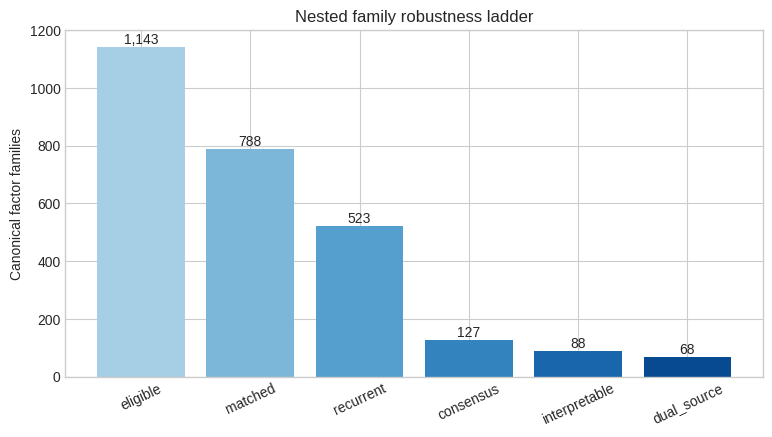

,cav_ready,tcav_valid,families
0,False,False,7737
1,True,False,33
2,True,True,6


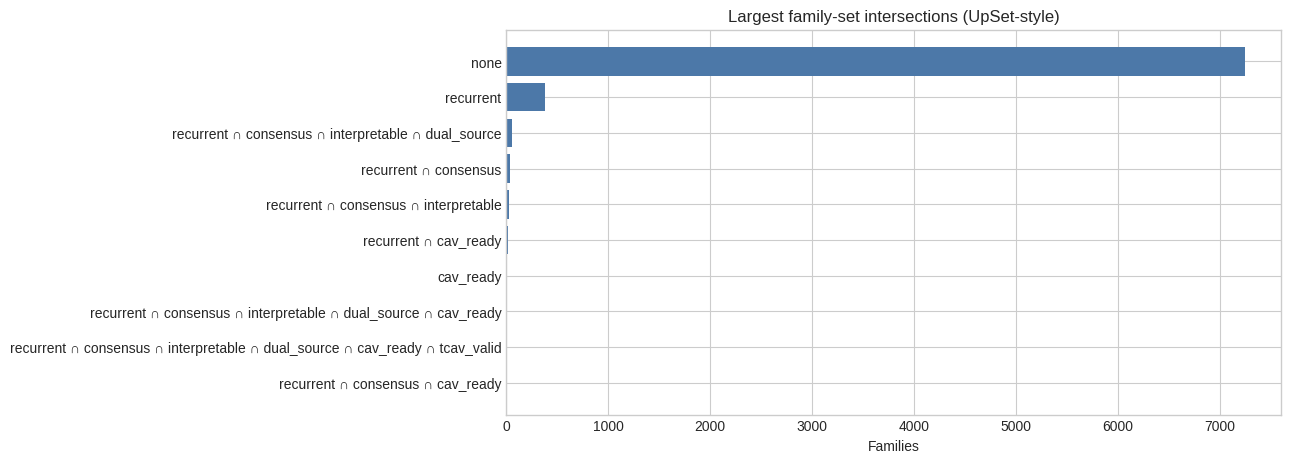

In [3]:
ladder = DERIVED['family_ladder'].copy()
stages = ['eligible', 'matched', 'recurrent', 'consensus', 'interpretable', 'dual_source']
stage_counts = pd.DataFrame({
    'stage': stages,
    'families': [int(ladder[stage].sum()) for stage in stages],
})
stage_counts['lost_from_previous'] = stage_counts['families'].shift(fill_value=len(ladder)) - stage_counts['families']
display(stage_counts)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(stage_counts['stage'], stage_counts['families'], color=plt.cm.Blues(np.linspace(.35, .9, len(stages))))
for index, row in stage_counts.iterrows():
    ax.text(index, row['families'], f"{row['families']:,}", ha='center', va='bottom')
ax.set(title='Nested family robustness ladder', ylabel='Canonical factor families')
ax.tick_params(axis='x', rotation=25)
plt.show()

badges = ladder.groupby(['cav_ready', 'tcav_valid'], dropna=False).size().rename('families').reset_index()
display(badges)
signature_columns = ['recurrent', 'consensus', 'interpretable', 'dual_source', 'cav_ready', 'tcav_valid']
overlap = (ladder.groupby(signature_columns, dropna=False).size().rename('families').reset_index()
           .sort_values('families', ascending=False).head(15))
overlap['signature'] = overlap.apply(lambda row: ' ∩ '.join(name for name in signature_columns if row[name]) or 'none', axis=1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(overlap['signature'][::-1], overlap['families'][::-1], color='#4c78a8')
ax.set(title='Largest family-set intersections (UpSet-style)', xlabel='Families')
plt.show()

## 3. Matching robustness

The headline views use cosine 0.60, overlap 0.70, P70 overlap masks, and recurrence strictly greater than 0.50. The sensitivity heatmaps below remain descriptive and do not retune that headline configuration.

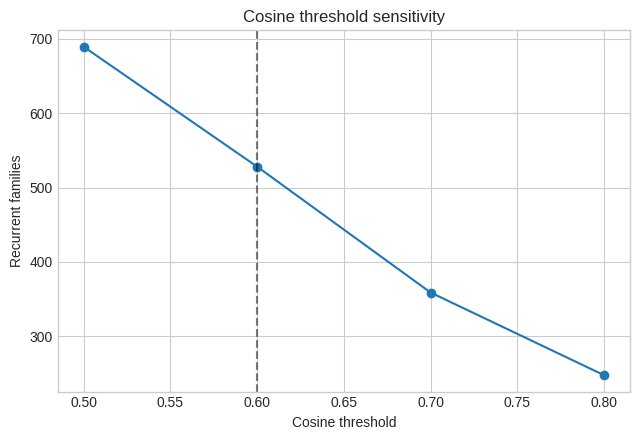

/tmp/ipykernel_425073/101689391.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


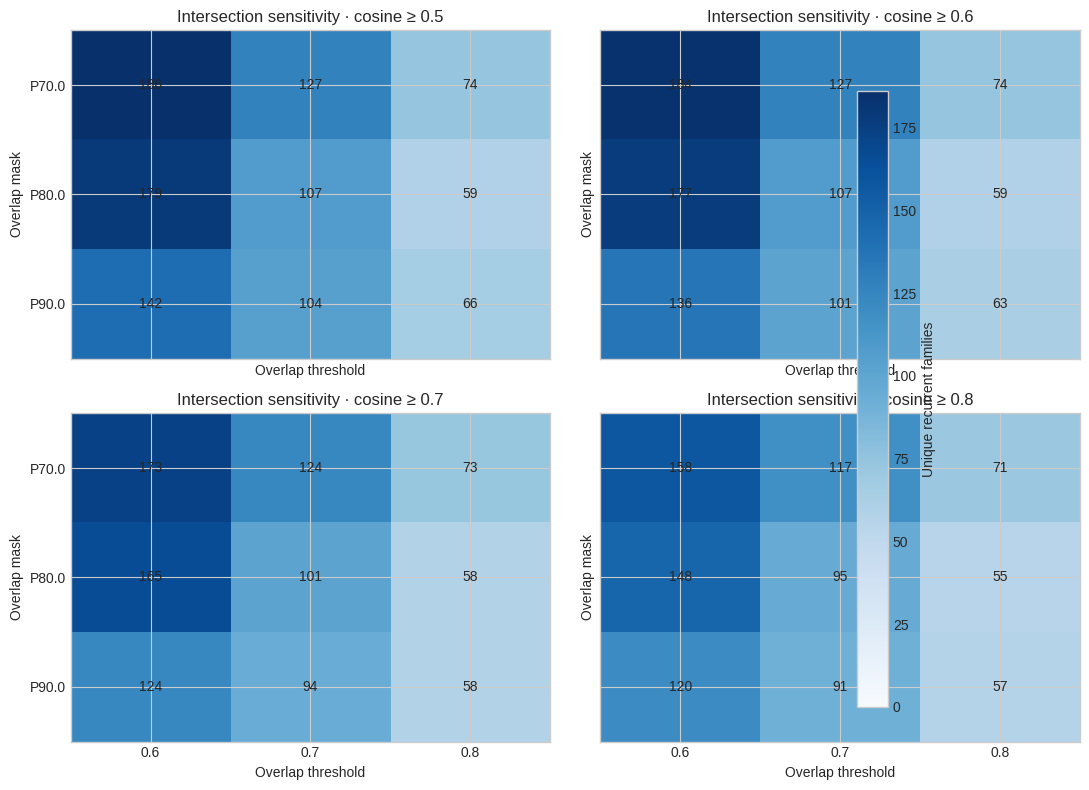

,configuration membership,families
0,neither,7248
1,cosine only,401
2,both,127


In [4]:
recurrence = PARENT_TABLES['matching_recurrence'].copy()
recurrence['recurrent_strict'] = pd.to_numeric(recurrence['recurrence'], errors='coerce').gt(RECURRENCE_MIN)
cosine_grid = (recurrence[recurrence['matching_view'].eq('cosine_qualified')]
               .groupby('cosine_threshold', as_index=False)['recurrent_strict'].sum())
intersection_grid = (recurrence[recurrence['matching_view'].eq('intersection') & recurrence['recurrent_strict']]
    .groupby(['cosine_threshold', 'overlap_percentile', 'overlap_threshold'])['factor_family_uid'].nunique().rename('recurrent_families').reset_index())
fig, axis = plt.subplots(figsize=(6.5, 4.5))
axis.plot(cosine_grid['cosine_threshold'], cosine_grid['recurrent_strict'], marker='o')
axis.axvline(COSINE_THRESHOLD, color='black', linestyle='--', alpha=.5)
axis.set(title='Cosine threshold sensitivity', xlabel='Cosine threshold', ylabel='Recurrent families')
fig.tight_layout(); plt.show()
cosine_thresholds = sorted(intersection_grid['cosine_threshold'].dropna().unique())
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
vmax = intersection_grid['recurrent_families'].max()
for axis, threshold in zip(axes.flat, cosine_thresholds):
    pivot = (intersection_grid[intersection_grid['cosine_threshold'].eq(threshold)]
        .pivot(index='overlap_percentile', columns='overlap_threshold', values='recurrent_families')
        .reindex(index=sorted(intersection_grid['overlap_percentile'].unique()), columns=sorted(intersection_grid['overlap_threshold'].unique())))
    image = axis.imshow(pivot, aspect='auto', cmap='Blues', vmin=0, vmax=vmax)
    axis.set(xticks=range(len(pivot.columns)), xticklabels=pivot.columns, yticks=range(len(pivot.index)), yticklabels=[f'P{x}' for x in pivot.index], xlabel='Overlap threshold', ylabel='Overlap mask', title=f'Intersection sensitivity · cosine ≥ {threshold:.1f}')
    for y in range(len(pivot.index)):
        for x in range(len(pivot.columns)):
            value = pivot.iloc[y, x]
            axis.text(x, y, '' if pd.isna(value) else int(value), ha='center', va='center')
fig.colorbar(image, ax=axes.ravel().tolist(), label='Unique recurrent families')
fig.tight_layout(); plt.show()

headline = recurrence[
    recurrence['cosine_threshold'].eq(COSINE_THRESHOLD)
    & recurrence['matching_view'].isin(['cosine_qualified', 'intersection'])
].copy()
headline = headline[(headline['matching_view'].eq('cosine_qualified')) | (
    headline['overlap_percentile'].eq(OVERLAP_PERCENTILE) & headline['overlap_threshold'].eq(OVERLAP_THRESHOLD)
)]
diagnostic = (headline.pivot_table(index='factor_family_uid', columns='matching_view', values='recurrent_strict', aggfunc='max', fill_value=False).reset_index())
diagnostic['membership'] = np.select([
    diagnostic.get('cosine_qualified', False) & diagnostic.get('intersection', False),
    diagnostic.get('cosine_qualified', False), diagnostic.get('intersection', False),
], ['both', 'cosine only', 'intersection only'], default='neither')
display(diagnostic['membership'].value_counts().rename_axis('configuration membership').reset_index(name='families'))

## 4. Rule quality and interpretability

Semantic rules are the headline explanation source. High-precision rules remain visible in secondary panels on exactly the same axes; they are not called primary and do not replace the semantic estimand.

/tmp/ipykernel_425073/2808385832.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=[TARGET_LABEL[target] for target in ACTIVATION_TARGETS], showfliers=False)
/tmp/ipykernel_425073/2808385832.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=[TARGET_LABEL[target] for target in ACTIVATION_TARGETS], showfliers=False)
/tmp/ipykernel_425073/2808385832.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=[TARGET_LABEL[target] for target in ACTIVATION_TARGETS], showfliers=False)
/tmp/ipykernel_425073/2808385832.py:9: MatplotlibDeprecationW

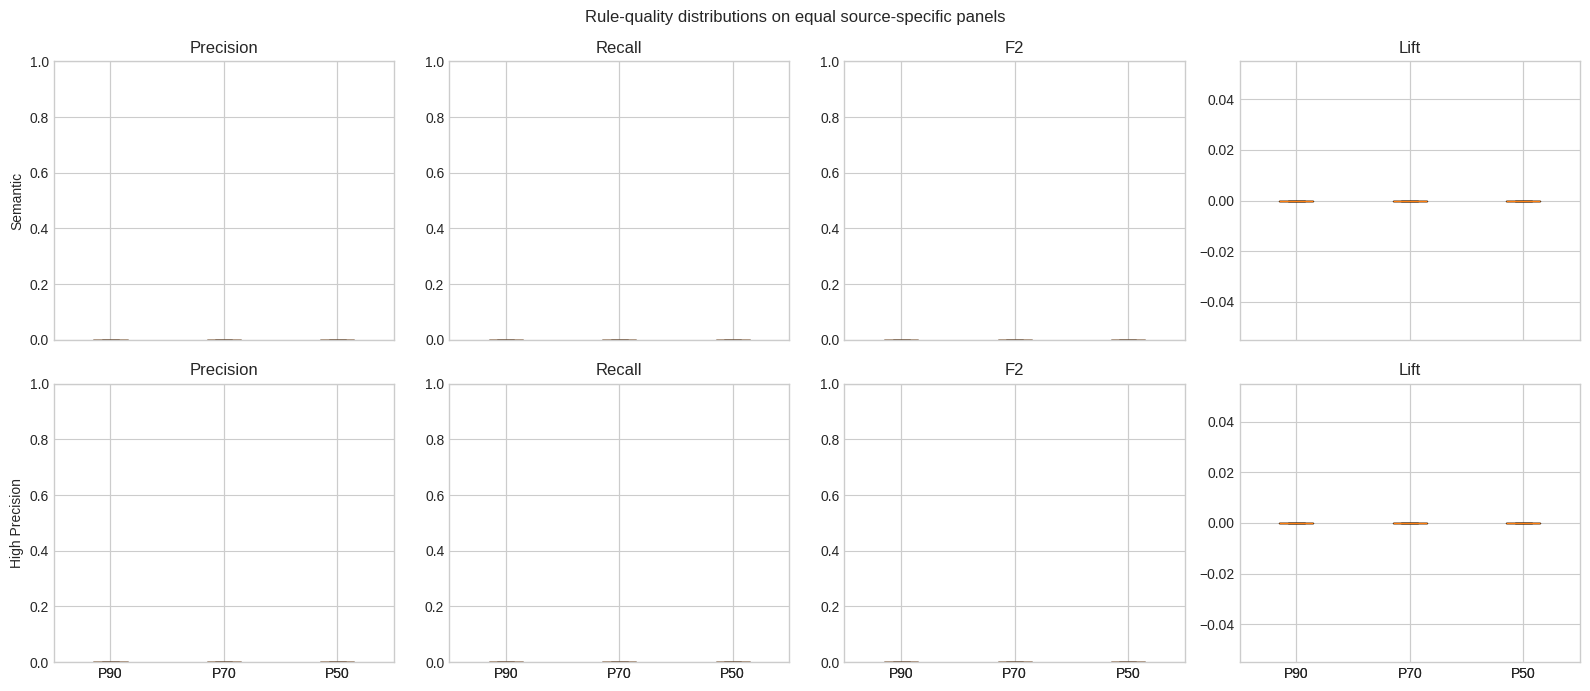

,rule_source,activation_target,attempted,valid,families,precision,recall,f2,activation_percentile
0,high_precision,0.1,10315,21,5127,0.044994,0.038608,0.032448,P90
1,high_precision,0.3,10315,299,5127,0.095582,0.044258,0.048292,P70
2,high_precision,0.5,10315,511,5127,0.101440,0.045400,0.050084,P50
3,semantic,0.1,10315,859,5127,0.065611,0.047880,0.048524,P90
4,semantic,0.3,10315,1312,5127,0.105727,0.062729,0.065467,P70
5,semantic,0.5,10315,1515,5127,0.122561,0.063528,0.067710,P50


,criterion,denominator_distinct_factor_count,denominator_distinct_family_count,denominator_factor_target_count,distinct_factor_count,distinct_factor_rate,distinct_family_count,distinct_family_rate,factor_target_count,factor_target_rate,summary_kind,summary_scope,activation_target,reference_year
0,insufficient_high_activation_support,10315,5127,30945,5253,0.509258,3314,0.646382,6820,0.220391,exclusive_funnel,overall,NaN,NaN
1,insufficient_selection_support,10315,5127,30945,108,0.010470,107,0.020870,108,0.003490,exclusive_funnel,overall,NaN,NaN
2,no_eligible_rule_length,10315,5127,30945,3,0.000291,3,0.000585,3,0.000097,exclusive_funnel,overall,NaN,NaN
3,no_feasible_subset,10315,5127,30945,3268,0.316820,2462,0.480203,4250,0.137340,exclusive_funnel,overall,NaN,NaN
4,no_recurrent_family,10315,5127,30945,8544,0.828308,4605,0.898186,16078,0.519567,exclusive_funnel,overall,NaN,NaN
5,selected,10315,5127,30945,2292,0.222201,1532,0.298810,3686,0.119115,exclusive_funnel,overall,NaN,NaN
6,max_rule_length,9478,4926,19994,3,0.000317,3,0.000609,3,0.000150,overlapping_ablation_rescue,overall,NaN,NaN
7,max_rules,9478,4926,19994,0,0.000000,0,0.000000,0,0.000000,overlapping_ablation_rescue,overall,NaN,NaN
8,min_lift,9478,4926,19994,0,0.000000,0,0.000000,0,0.000000,overlapping_ablation_rescue,overall,NaN,NaN
9,min_marginal_recall,9478,4926,19994,0,0.000000,0,0.000000,0,0.000000,overlapping_ablation_rescue,overall,NaN,NaN


In [5]:
rules = PARENT_TABLES['rules'].copy()
rules = rules[rules['activation_target'].isin(ACTIVATION_TARGETS)]
quality = ['precision', 'recall', 'f2', 'lift']
fig, axes = plt.subplots(2, len(quality), figsize=(16, 7), sharex='col')
for row_index, source in enumerate(('semantic', 'high_precision')):
    selected = rules[rules['rule_source'].eq(source)]
    for axis, metric in zip(axes[row_index], quality):
        values = [pd.to_numeric(selected[selected['activation_target'].eq(target)][metric], errors='coerce').dropna() for target in ACTIVATION_TARGETS]
        axis.boxplot(values, labels=[TARGET_LABEL[target] for target in ACTIVATION_TARGETS], showfliers=False)
        axis.set_title(metric.replace('_', ' ').title())
        if metric != 'lift': axis.set_ylim(0, 1)
        if axis is axes[row_index, 0]: axis.set_ylabel(source.replace('_', ' ').title())
fig.suptitle('Rule-quality distributions on equal source-specific panels')
fig.tight_layout(); plt.show()
rule_summary = (rules.groupby(['rule_source', 'activation_target'], as_index=False)
    .agg(attempted=('factor_family_uid', 'size'), valid=('valid', 'sum'), families=('factor_family_uid', 'nunique'), precision=('precision', 'mean'), recall=('recall', 'mean'), f2=('f2', 'mean')))
rule_summary['activation_percentile'] = rule_summary['activation_target'].map(TARGET_LABEL)
display(rule_summary)
display(PARENT_TABLES['semantic_selection_summary'].head(30))

/tmp/ipykernel_425073/3422989662.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=labels, showfliers=False)
/tmp/ipykernel_425073/3422989662.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=labels, showfliers=False)
/tmp/ipykernel_425073/3422989662.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=labels, showfliers=False)
/tmp/ipykernel_425073/3422989662.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


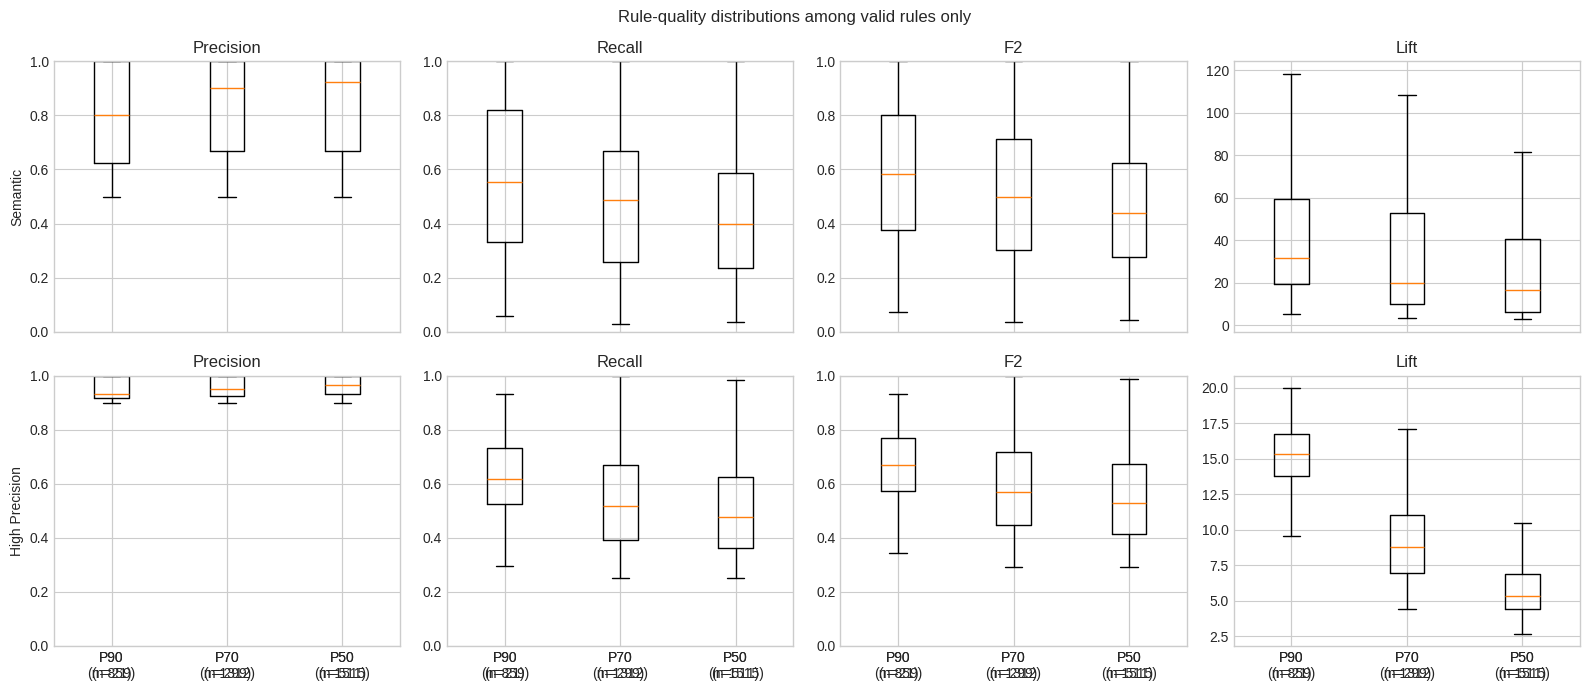

,rule_source,activation_target,valid_rules,families,precision,recall,f2
0,high_precision,0.1,21,14,0.946523,0.630236,0.670514
1,high_precision,0.3,299,179,0.957847,0.542577,0.587150
2,high_precision,0.5,511,292,0.962779,0.507012,0.553466
3,semantic,0.1,859,585,0.787865,0.574955,0.582684
4,semantic,0.3,1312,943,0.831226,0.493178,0.514703
5,semantic,0.5,1515,1123,0.834466,0.432538,0.461009


In [6]:
valid_rules = rules[rules['valid'].eq(True)].copy()
fig, axes = plt.subplots(2, len(quality), figsize=(16, 7), sharex='col')
for row_index, source in enumerate(('semantic', 'high_precision')):
    selected = valid_rules[valid_rules['rule_source'].eq(source)]
    counts = [int(selected['activation_target'].eq(target).sum()) for target in ACTIVATION_TARGETS]
    labels = [f"{TARGET_LABEL[target]}\n(n={count})" for target, count in zip(ACTIVATION_TARGETS, counts)]
    for axis, metric in zip(axes[row_index], quality):
        values = [pd.to_numeric(selected[selected['activation_target'].eq(target)][metric], errors='coerce').dropna() for target in ACTIVATION_TARGETS]
        axis.boxplot(values, labels=labels, showfliers=False)
        axis.set_title(metric.replace('_', ' ').title())
        if metric != 'lift': axis.set_ylim(0, 1)
        if axis is axes[row_index, 0]: axis.set_ylabel(source.replace('_', ' ').title())
fig.suptitle('Rule-quality distributions among valid rules only')
fig.tight_layout(); plt.show()
display(valid_rules.groupby(['rule_source', 'activation_target'], as_index=False).agg(valid_rules=('factor_family_uid', 'size'), families=('factor_family_uid', 'nunique'), precision=('precision', 'mean'), recall=('recall', 'mean'), f2=('f2', 'mean')))

## 5. Temporal robustness and model performance

Ribbons are 95% hierarchical bootstrap intervals, not standard deviations. Each figure fixes cohort, matching view, rule source, and activation percentile before aggregation. TCAV is shown only in its actual 0–1 score units. Model-performance curves always come from the original TabPFN system whose reference experiment supplies the concept-robustness measurements; zero death F1 values are retained as valid primary outcomes.

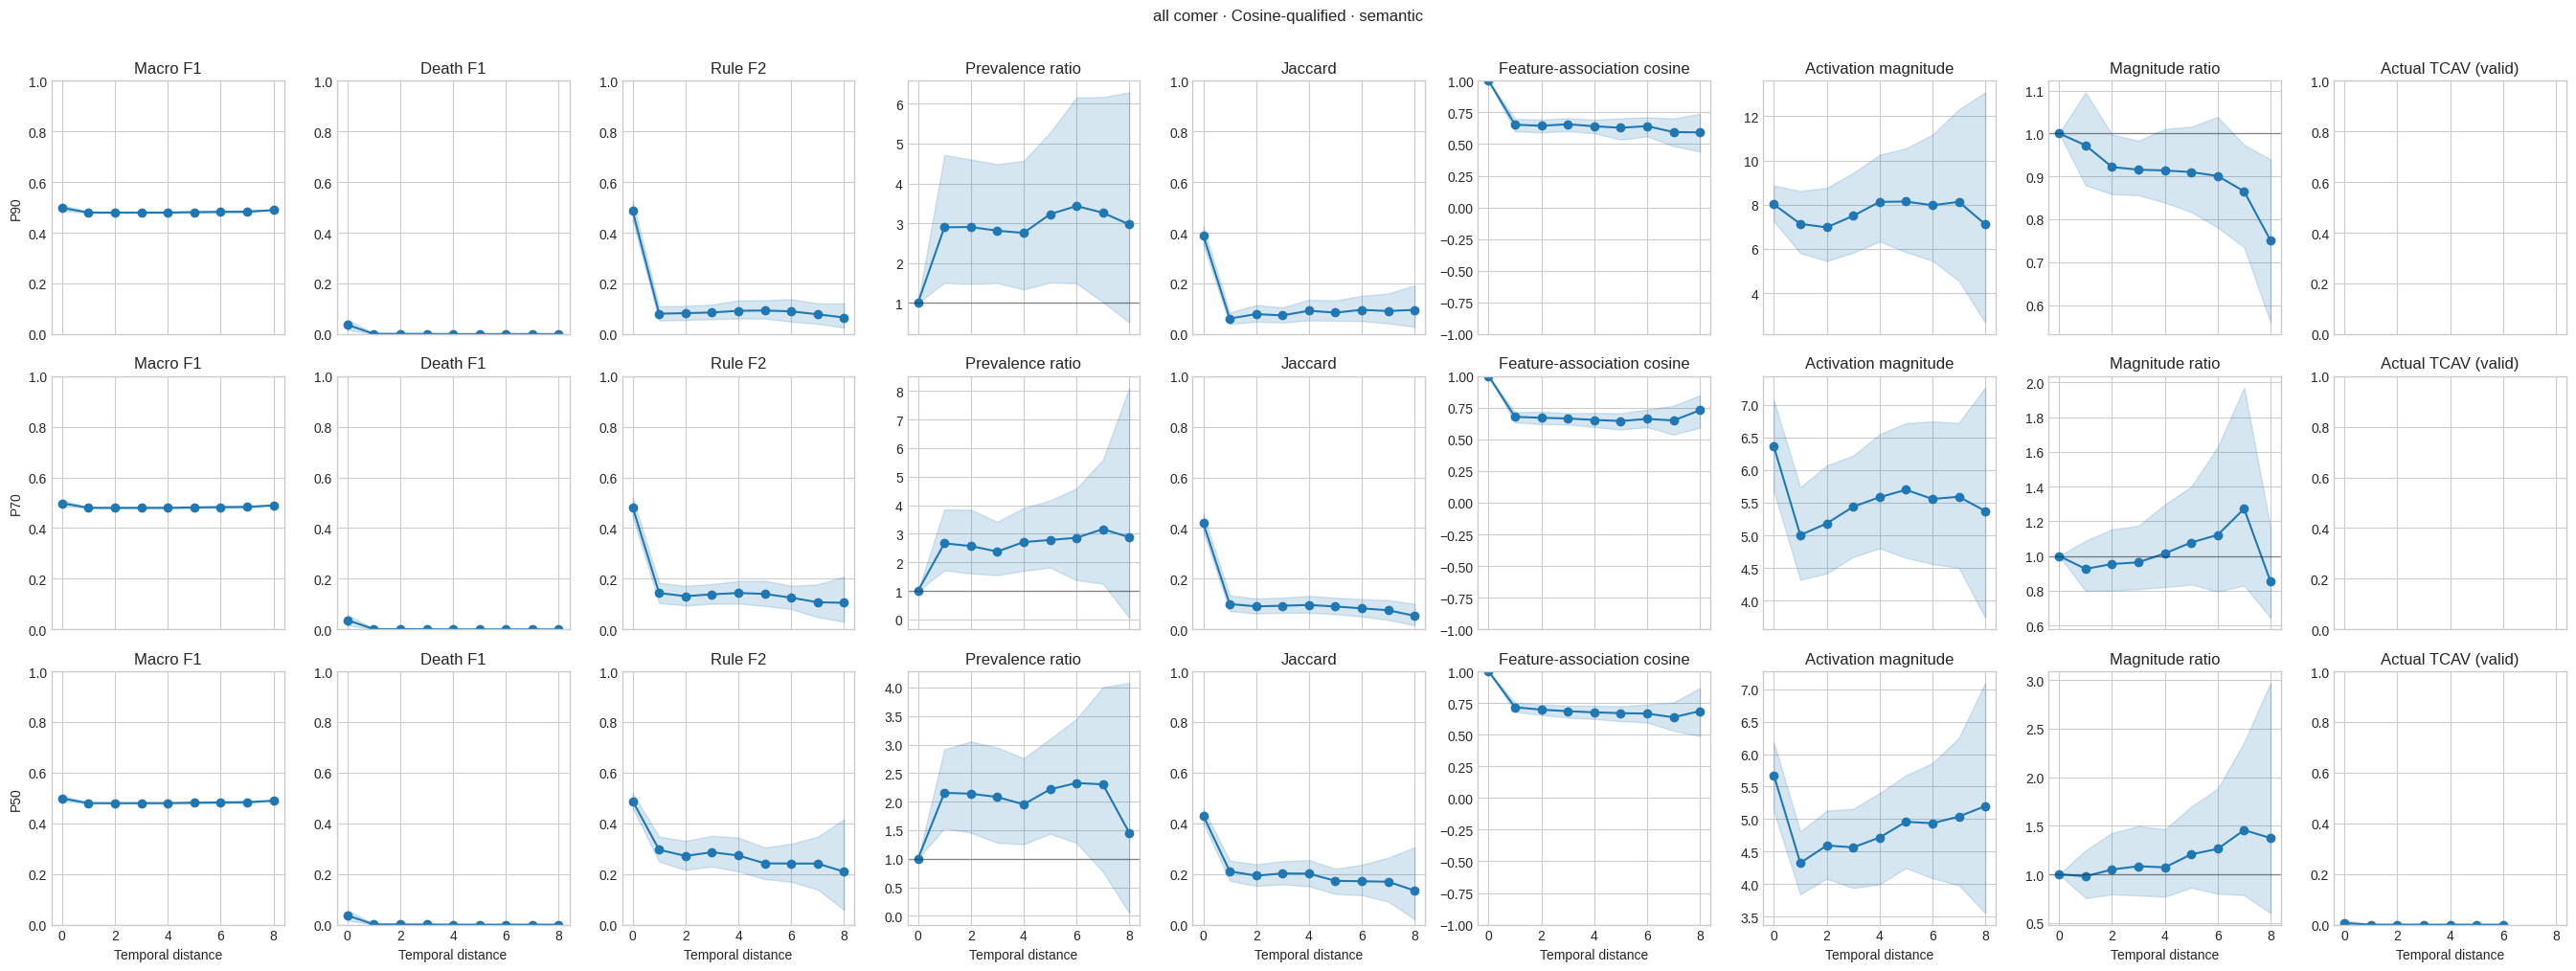

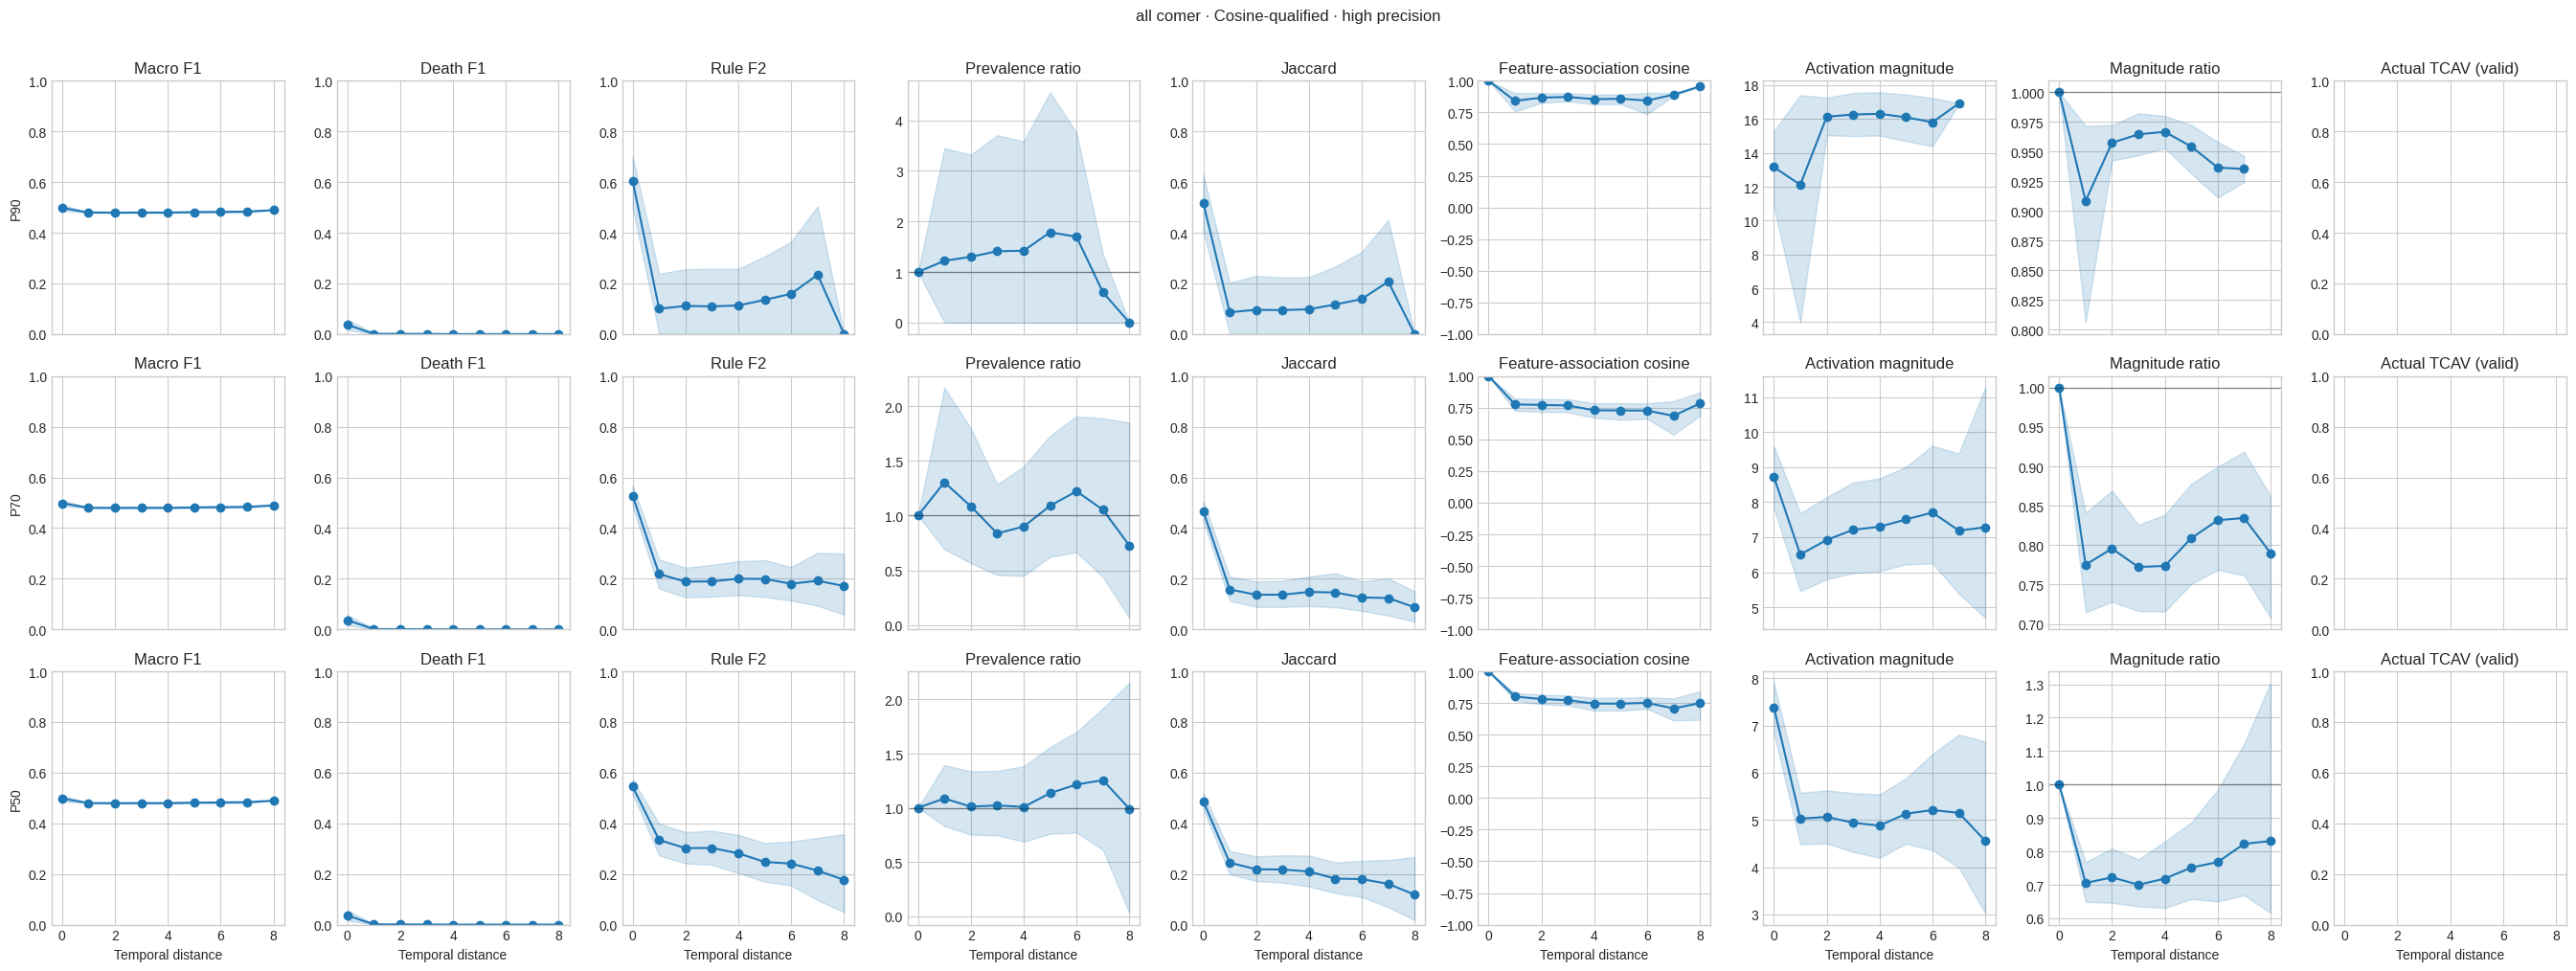

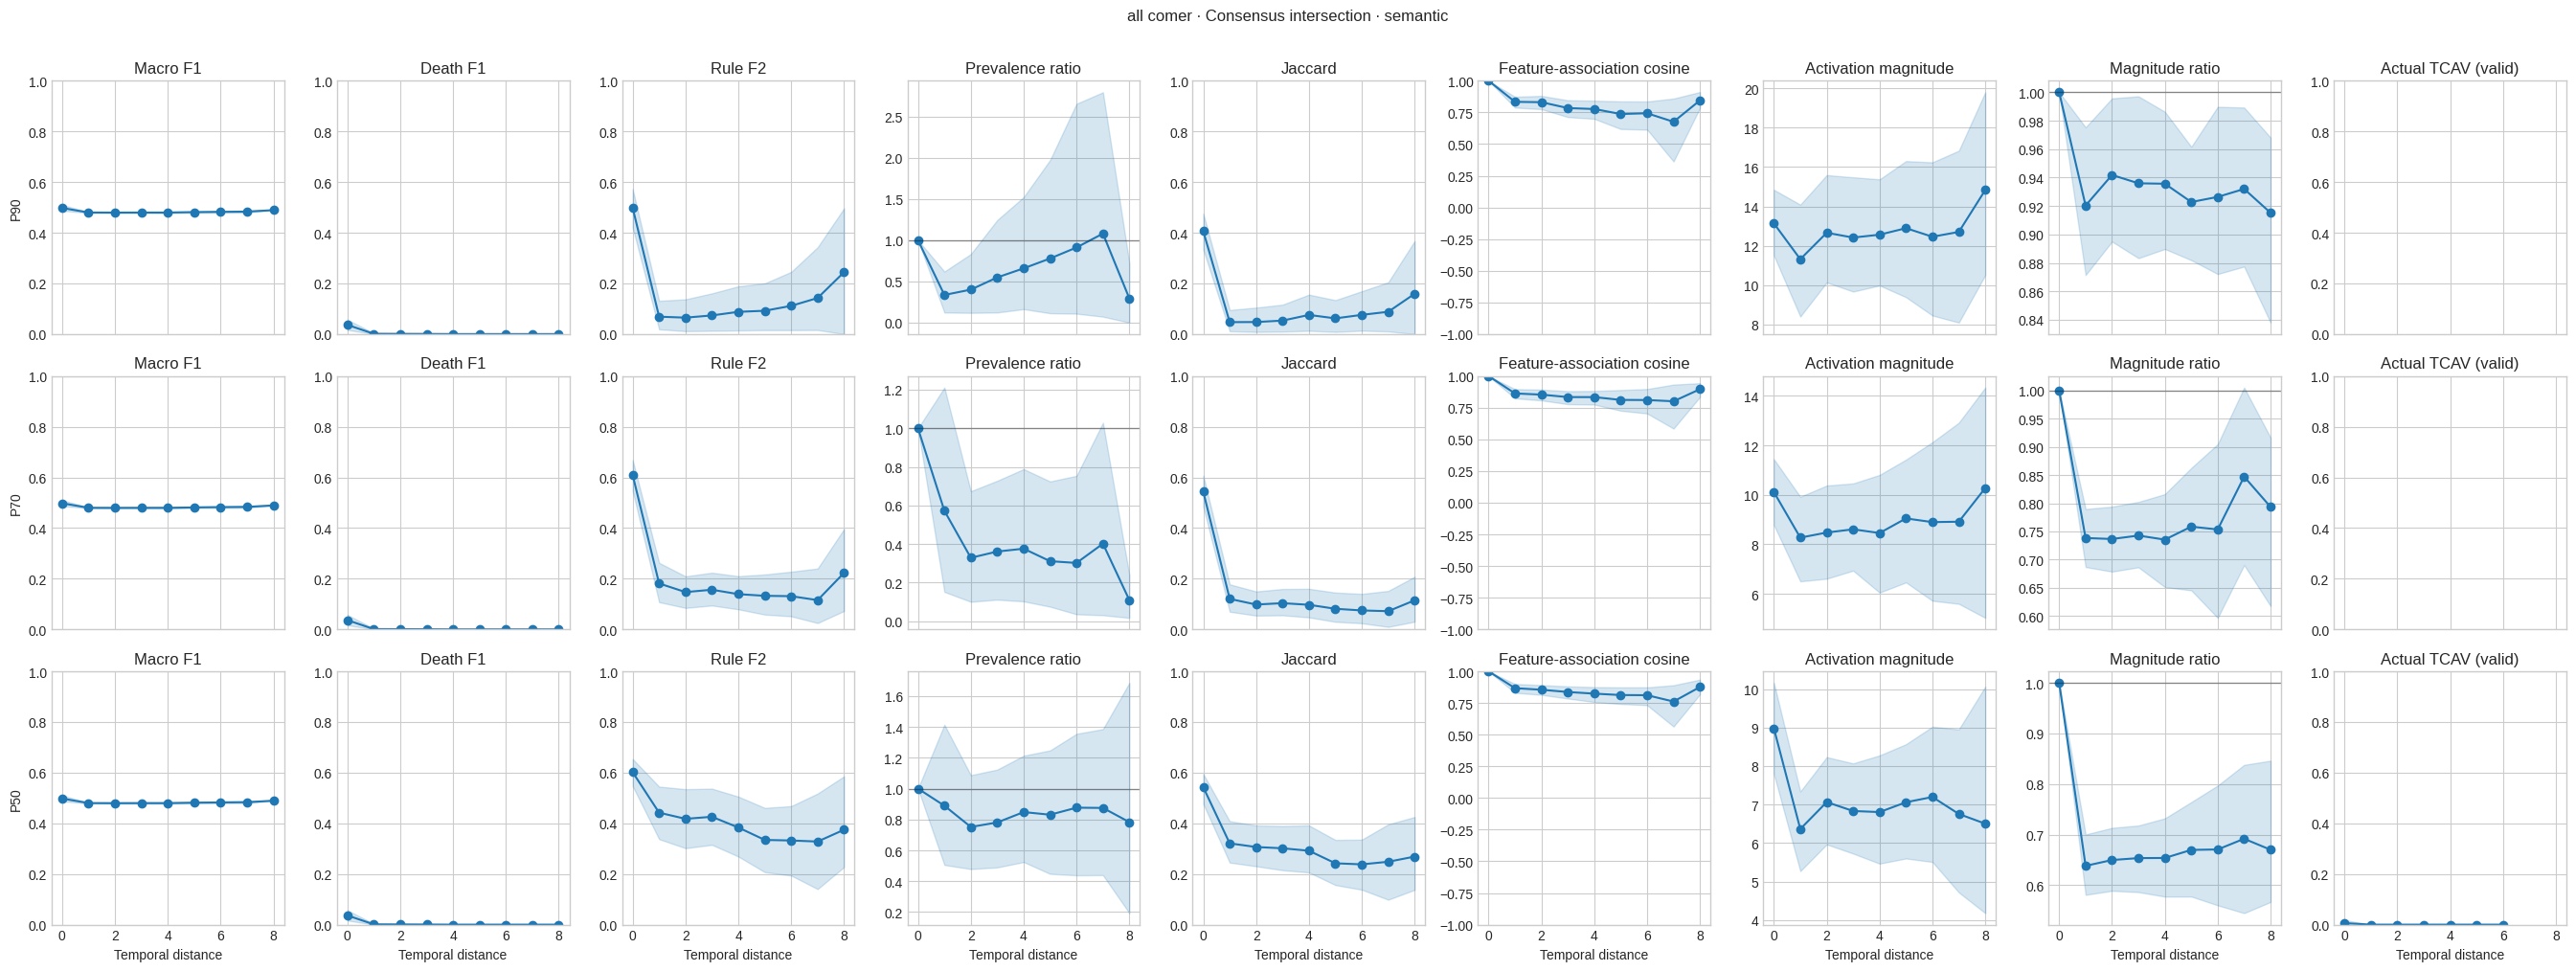

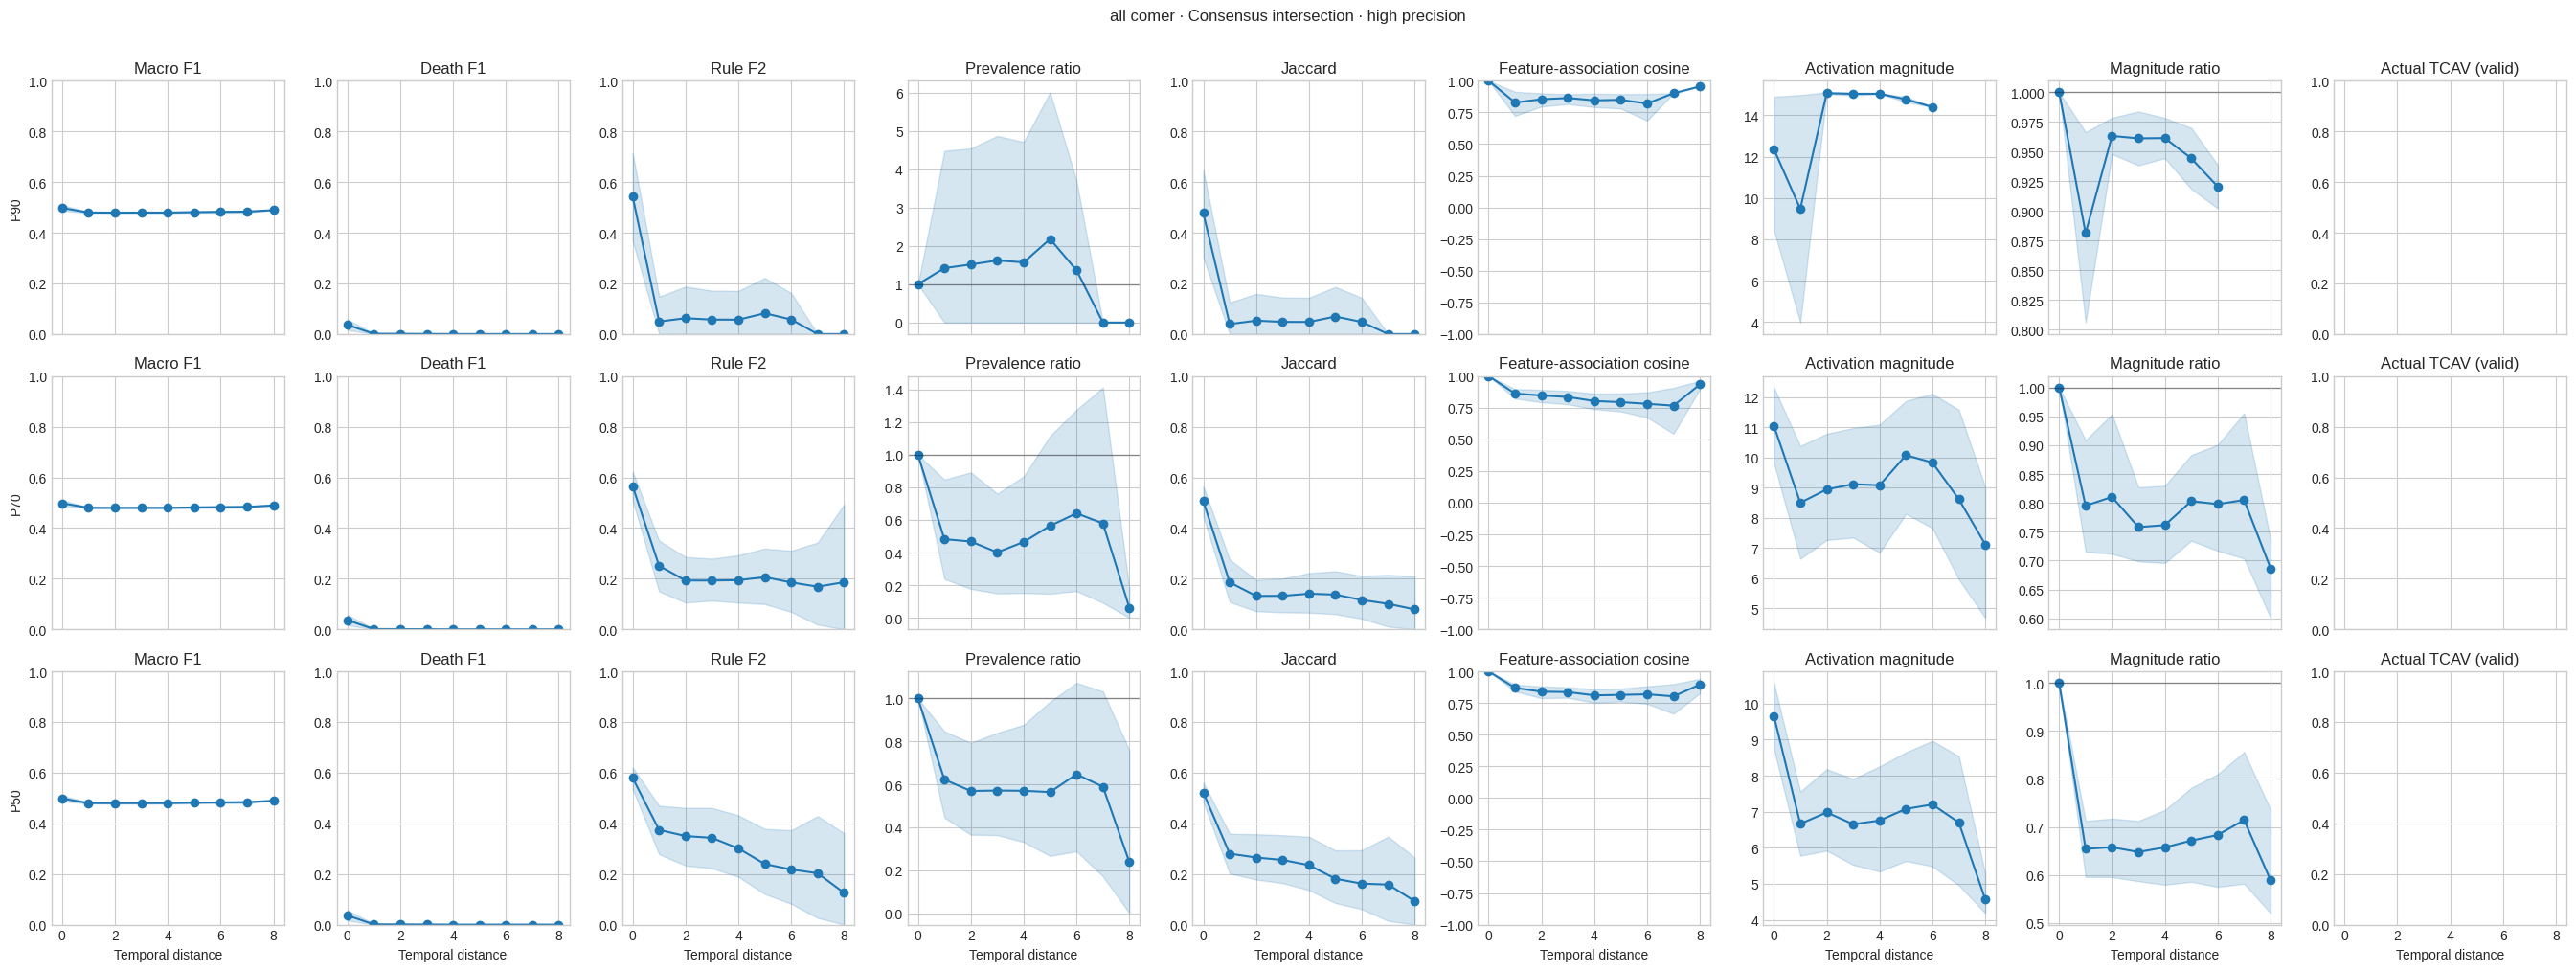

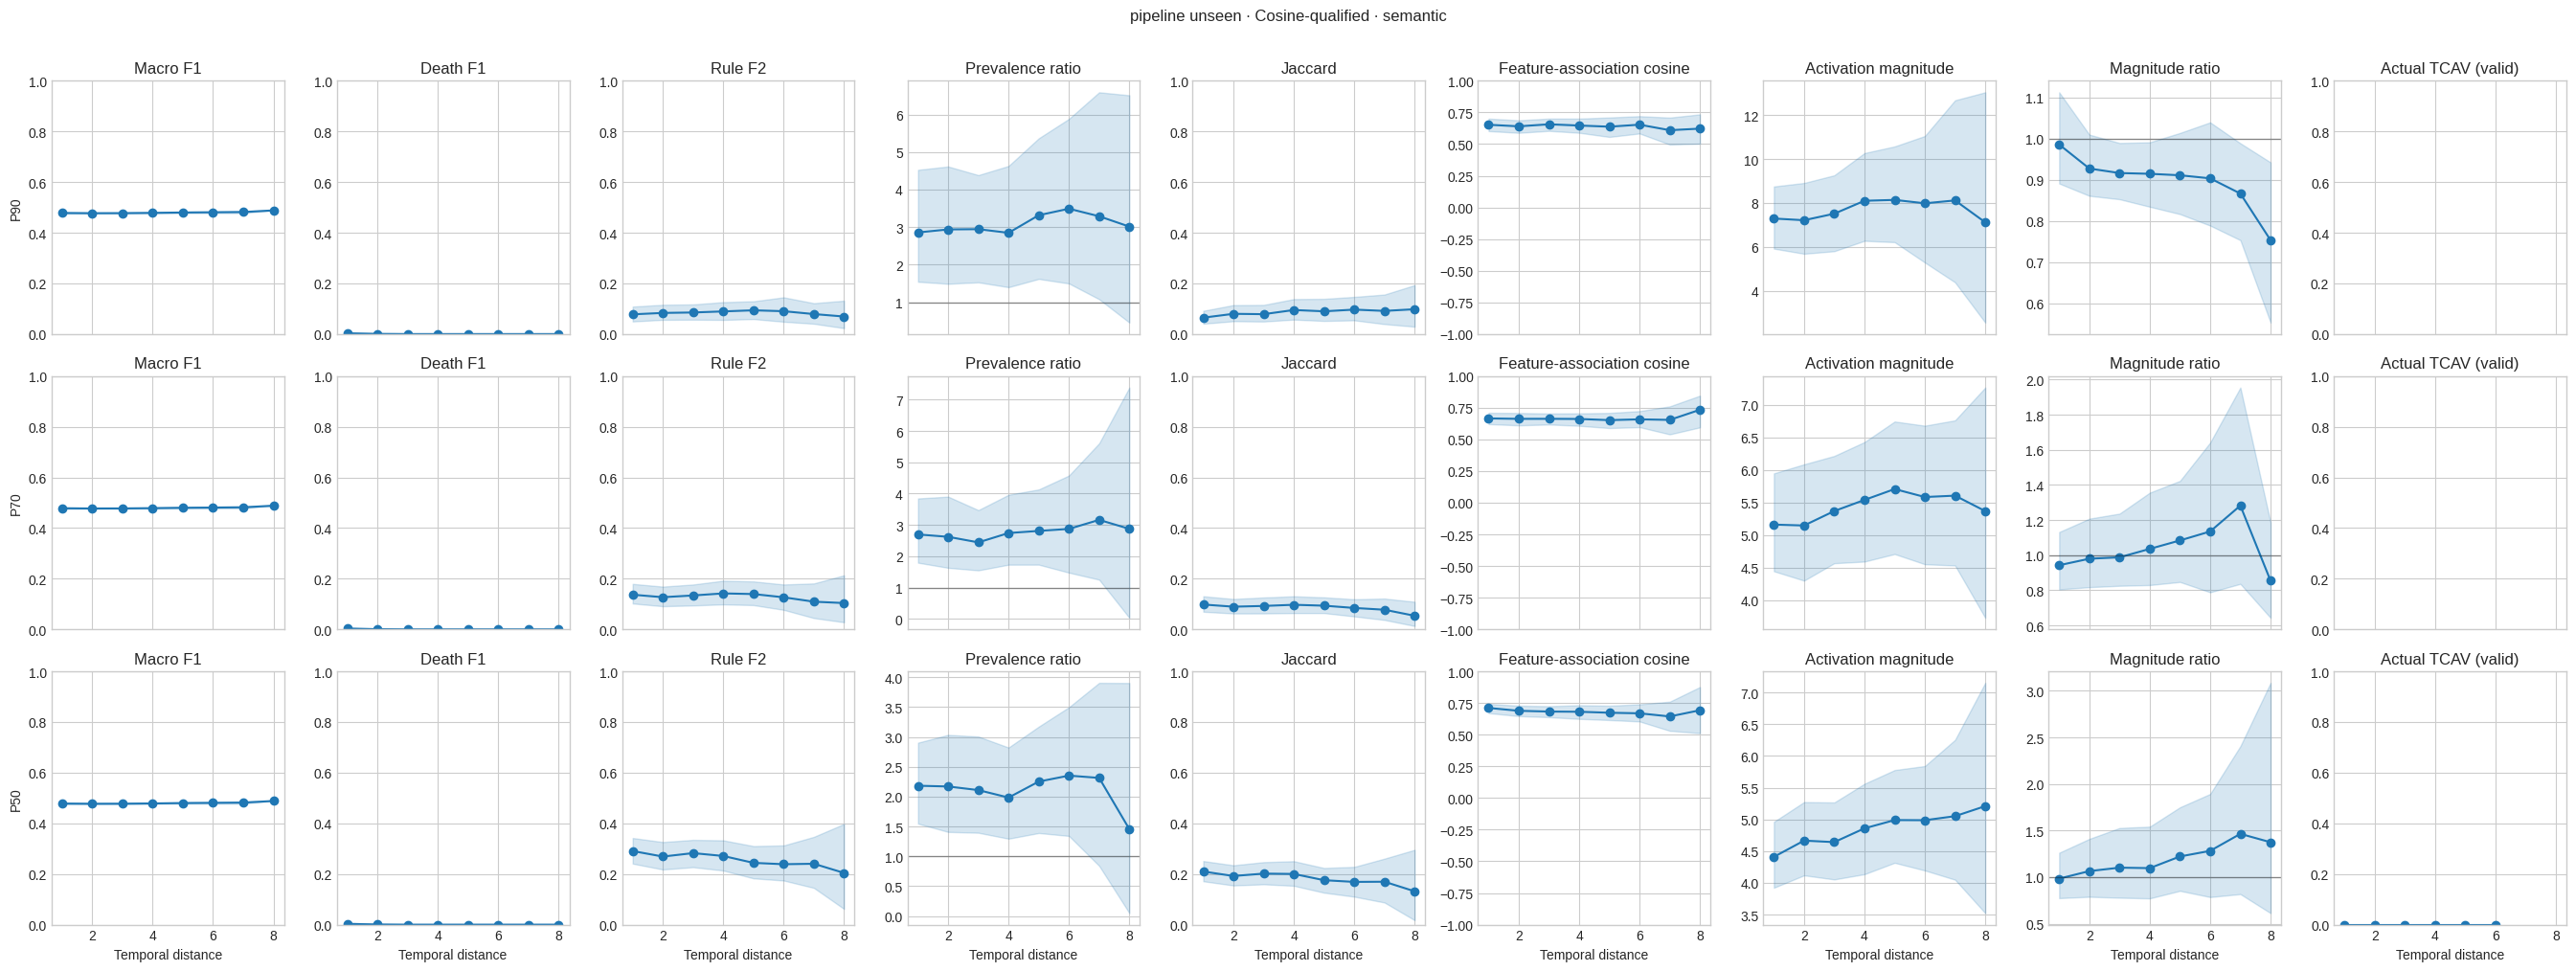

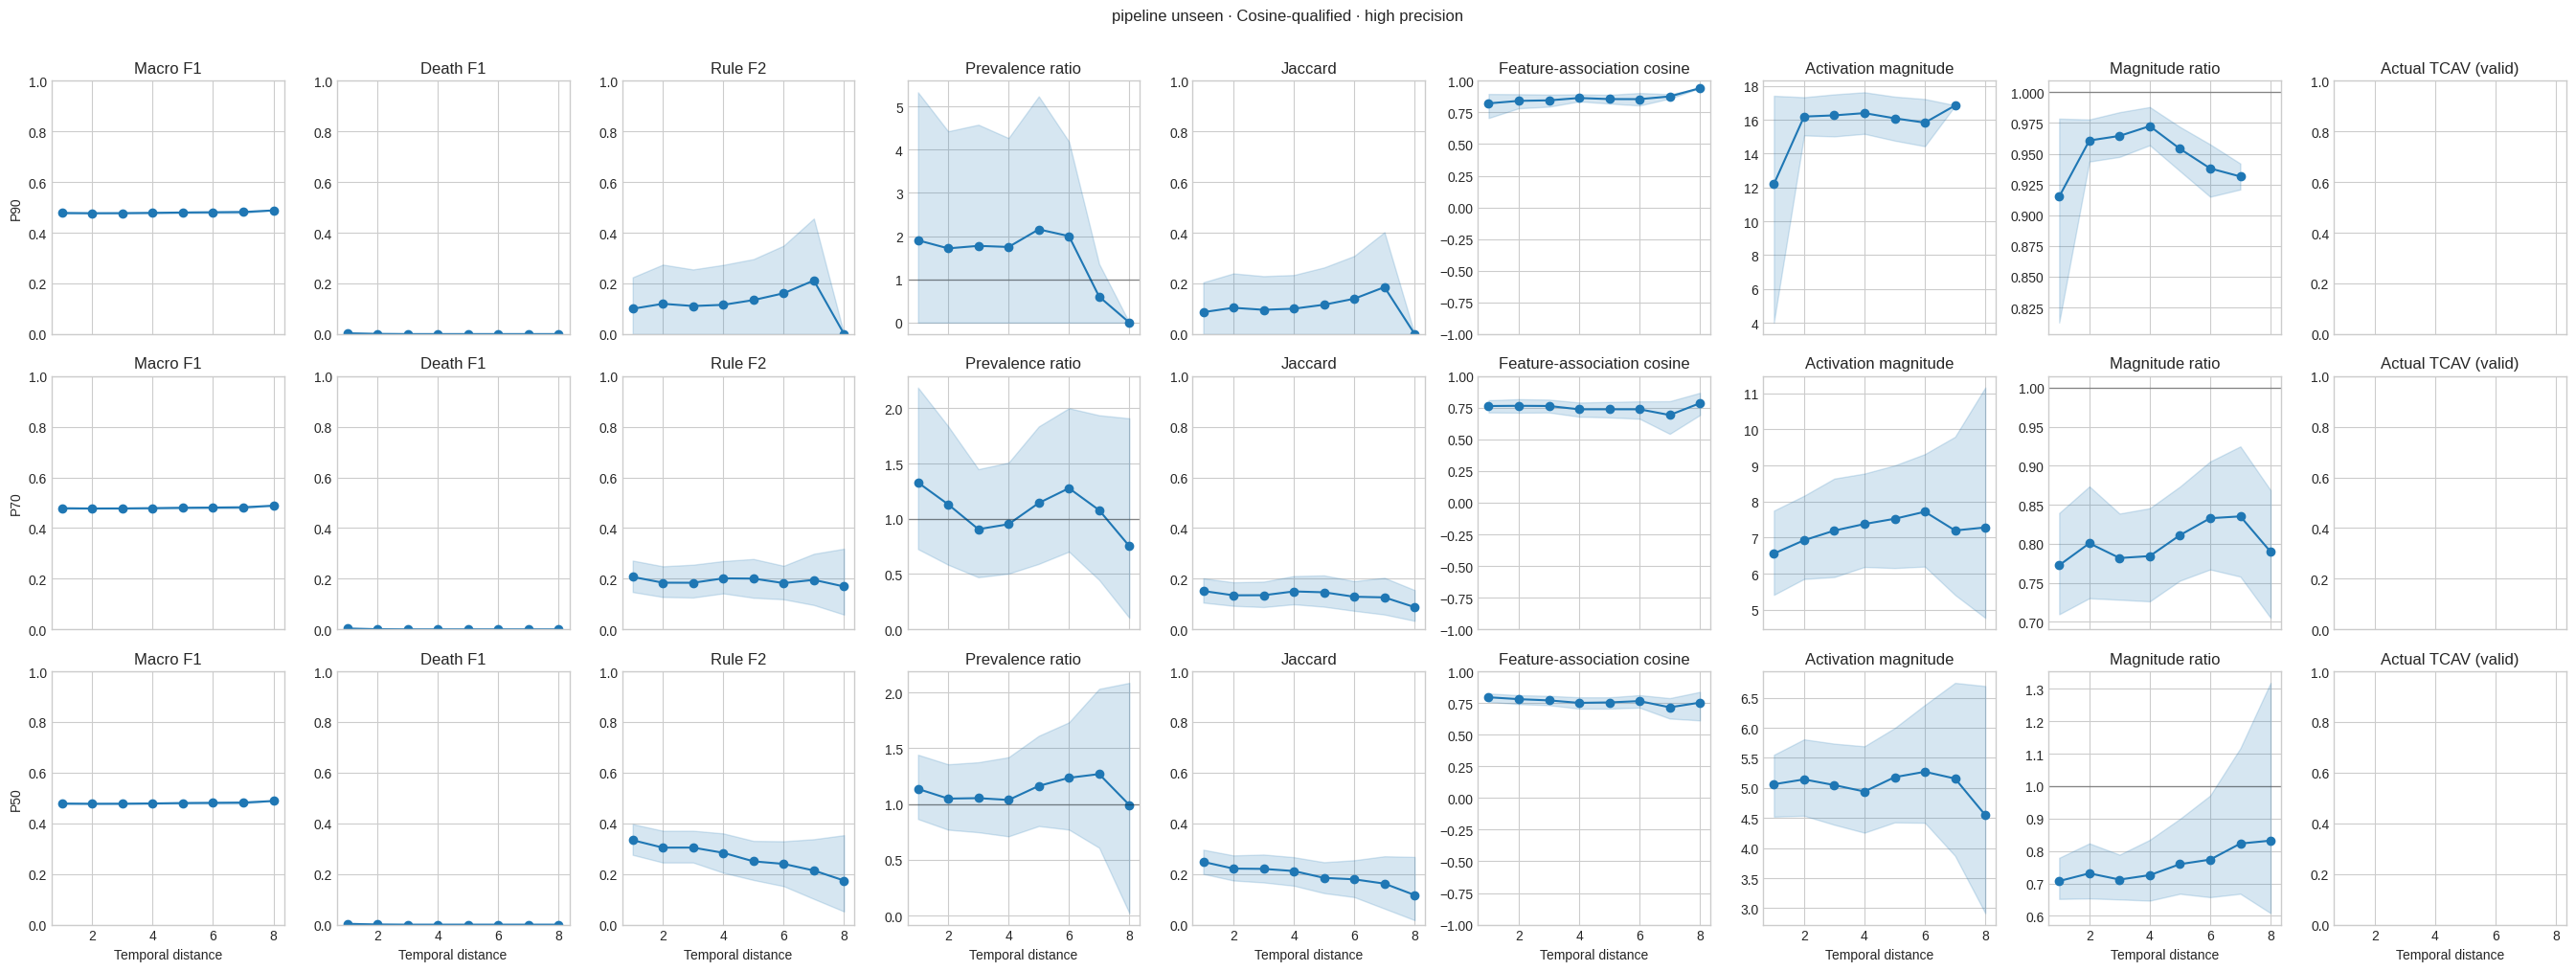

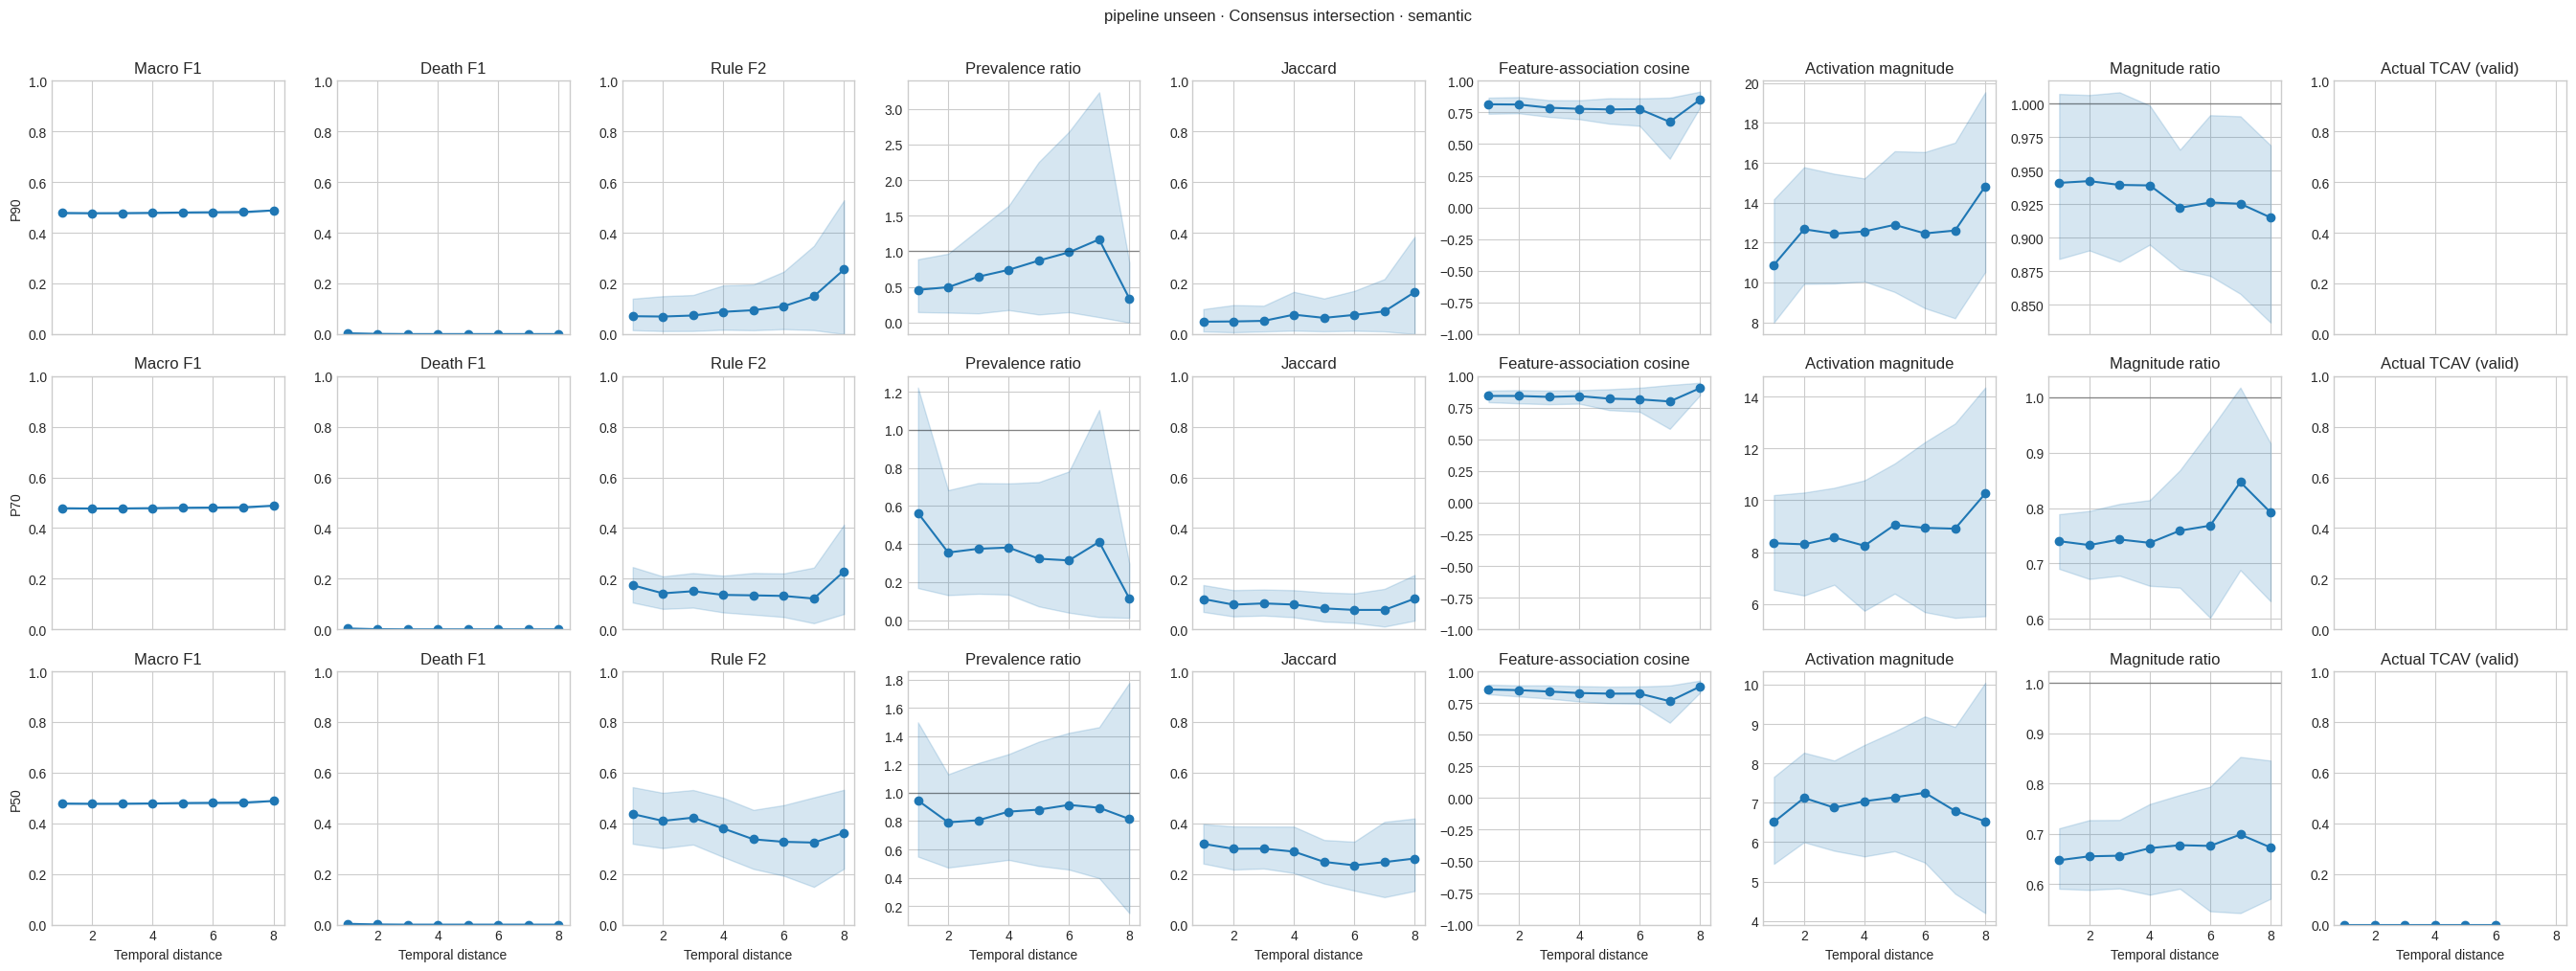

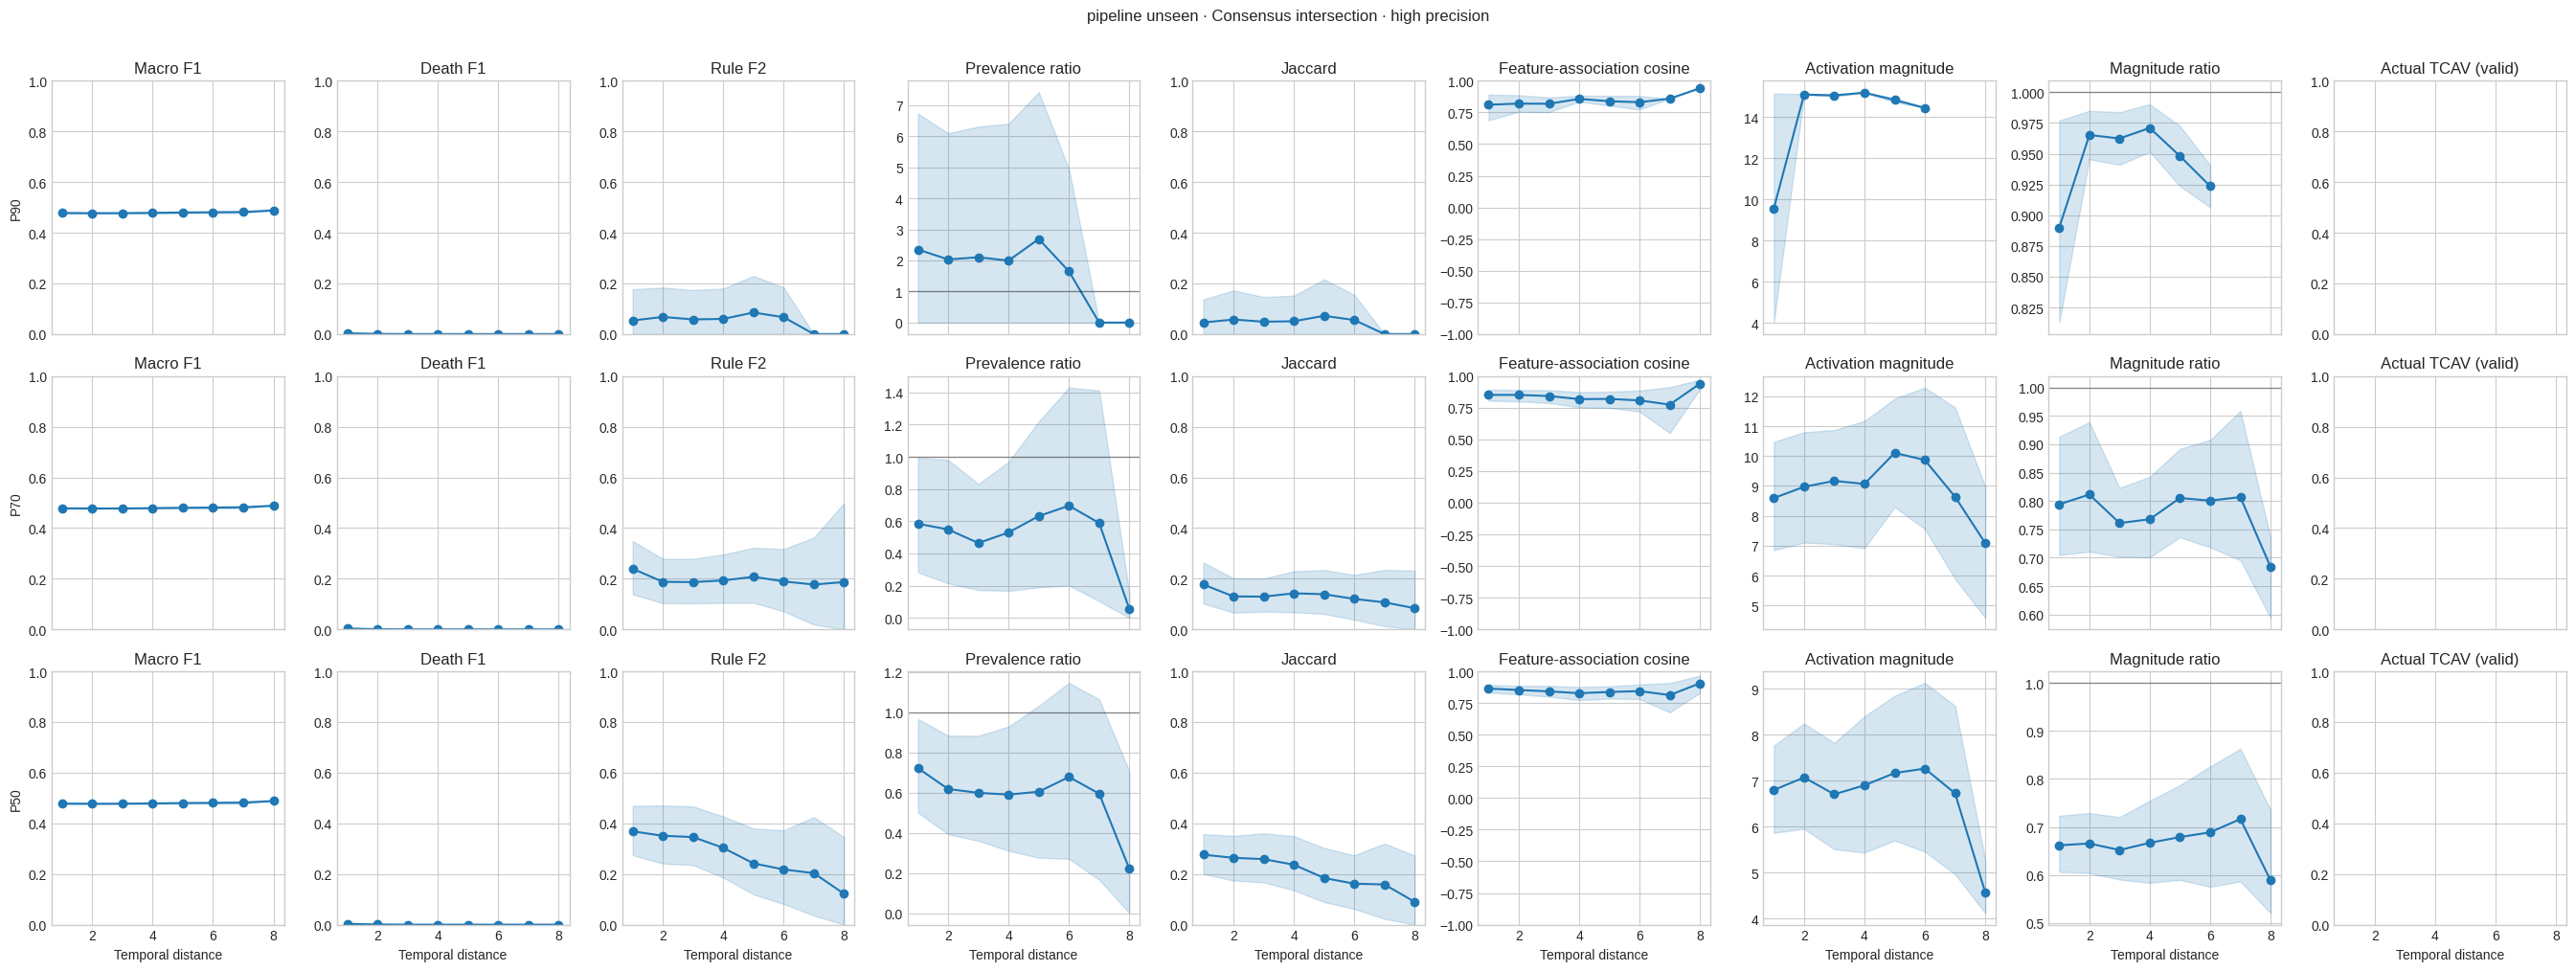

In [7]:
performance = DERIVED['primary_performance'].copy()
factors = DERIVED['headline_factor_metrics'].copy()
tcav_all = DERIVED['tcav_significance'].copy()
tcav = tcav_all[tcav_all['tcav_valid'].eq(True)].copy() if not tcav_all.empty else tcav_all
status = DERIVED['status_composition'].copy()

def hierarchical_trajectory(frame, metric, group_fields, unit_fields):
    rows = []
    for key, group in frame.groupby(list(group_fields), dropna=False):
        key = key if isinstance(key, tuple) else (key,)
        unit = group.groupby(list(unit_fields), dropna=False, as_index=False)[metric].mean().dropna(subset=[metric])
        if unit.empty: continue
        cluster_fields = [field for field in ('reference_year', 'patient_split_seed') if field in unit_fields]
        clusters = [rows[metric].to_numpy(float) for _, rows in unit.groupby(cluster_fields, dropna=False)]
        digest = hashlib.sha256(repr((metric, key)).encode()).hexdigest()
        seed = BOOTSTRAP_SEED + int(digest[:8], 16) % 100000
        rng = np.random.default_rng(seed)
        boot = []
        for _ in range(BOOTSTRAP_REPETITIONS):
            sampled_clusters = rng.integers(0, len(clusters), len(clusters))
            cluster_means = []
            for position in sampled_clusters:
                values = clusters[position]
                cluster_means.append(np.mean(values[rng.integers(0, len(values), len(values))]))
            boot.append(np.mean(cluster_means))
        low, high = np.percentile(boot, [2.5, 97.5])
        rows.append({**dict(zip(group_fields, key)), 'metric': metric, 'mean': float(np.mean([np.mean(values) for values in clusters])), 'lower_95': low, 'upper_95': high, 'support': len(unit)})
    return pd.DataFrame(rows)

performance_summary = pd.concat([hierarchical_trajectory(
    performance, metric, ('cohort_view', 'temporal_distance'), ('reference_year', 'patient_split_seed')
) for metric in ('macro_f1', 'death_f1')], ignore_index=True)
factor_summaries = []
for metric in ('f2', 'prevalence_ratio', 'jaccard', 'feature_association_cosine', 'activation_magnitude', 'activation_magnitude_ratio'):
    factor_summaries.append(hierarchical_trajectory(
        factors, metric, ('cohort_view', 'matching_view', 'rule_source', 'activation_target', 'temporal_distance'),
        ('reference_year', 'patient_split_seed', 'factor_family_uid', 'member_sae_seed', 'member_factor_id'),
    ))
factor_summary = pd.concat(factor_summaries, ignore_index=True)
tcav_summary = (pd.DataFrame() if tcav.empty else hierarchical_trajectory(
    tcav, 'tcav', ('cohort_view', 'matching_view', 'rule_source', 'activation_target', 'temporal_distance'),
    ('reference_year', 'patient_split_seed', 'factor_family_uid', 'member_sae_seed', 'member_factor_id'),
))

def ribbon(axis, rows, label, color=None):
    rows = rows.sort_values('temporal_distance')
    if rows.empty: return
    line = axis.plot(rows['temporal_distance'], rows['mean'], marker='o', label=label, color=color)[0]
    axis.fill_between(rows['temporal_distance'], rows['lower_95'], rows['upper_95'], color=line.get_color(), alpha=.18)

def aligned_native_panels(cohort, view, source):
    metrics = [('macro_f1', 'Macro F1'), ('death_f1', 'Death F1'), ('f2', 'Rule F2'), ('prevalence_ratio', 'Prevalence ratio'), ('jaccard', 'Jaccard'), ('feature_association_cosine', 'Feature-association cosine'), ('activation_magnitude', 'Activation magnitude'), ('activation_magnitude_ratio', 'Magnitude ratio'), ('tcav', 'Actual TCAV (valid)')]
    fig, axes = plt.subplots(len(ACTIVATION_TARGETS), len(metrics), figsize=(27, 10), sharex=True)
    for row_index, target in enumerate(ACTIVATION_TARGETS):
        for axis, (metric, label) in zip(axes[row_index], metrics):
            if metric in {'macro_f1', 'death_f1'}:
                selected = performance_summary[performance_summary['cohort_view'].eq(cohort) & performance_summary['metric'].eq(metric)]
            elif metric == 'tcav':
                selected = tcav_summary[(tcav_summary.get('cohort_view') == cohort) & (tcav_summary.get('matching_view') == view) & (tcav_summary.get('rule_source') == source) & (tcav_summary.get('activation_target') == target)] if not tcav_summary.empty else pd.DataFrame()
            else:
                selected = factor_summary[(factor_summary['cohort_view'].eq(cohort)) & (factor_summary['matching_view'].eq(view)) & (factor_summary['rule_source'].eq(source)) & (factor_summary['activation_target'].eq(target)) & (factor_summary['metric'].eq(metric))]
            ribbon(axis, selected, TARGET_LABEL[target])
            axis.set_title(label)
            if metric in {'macro_f1', 'death_f1', 'f2', 'jaccard', 'tcav'}: axis.set_ylim(0, 1)
            if metric == 'feature_association_cosine': axis.set_ylim(-1, 1)
            if metric in {'prevalence_ratio', 'activation_magnitude_ratio'}: axis.axhline(1, color='black', linewidth=1, alpha=.35)
            if row_index == len(ACTIVATION_TARGETS)-1: axis.set_xlabel('Temporal distance')
        axes[row_index, 0].set_ylabel(TARGET_LABEL[target])
    fig.suptitle(f"{cohort.replace('_', ' ')} · {VIEW_LABEL[view]} · {source.replace('_', ' ')}", y=1.01)
    fig.tight_layout(); plt.show()

for cohort in COHORTS:
    for view in ('cosine_qualified', 'intersection'):
        aligned_native_panels(cohort, view, 'semantic')
        aligned_native_panels(cohort, view, 'high_precision')

### Normalized overview

Each curve is divided by its own first finite measurement. Pipeline-unseen therefore begins at its first available future distance. Zero baselines remain unavailable and are not silently replaced. TCAV is deliberately excluded.

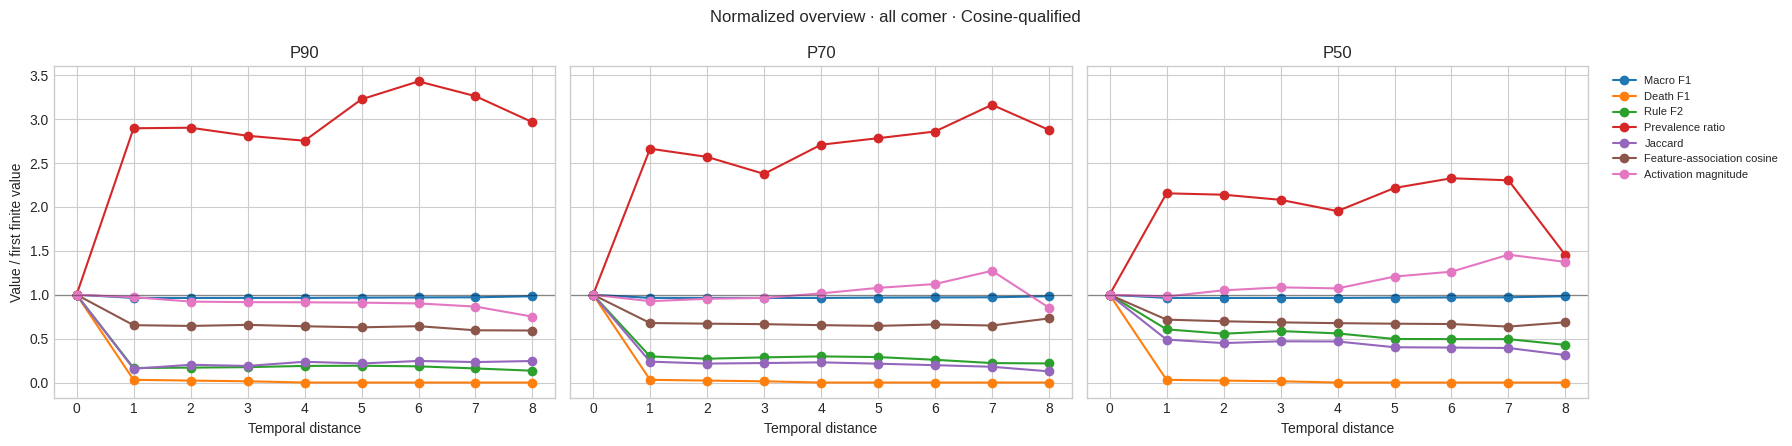

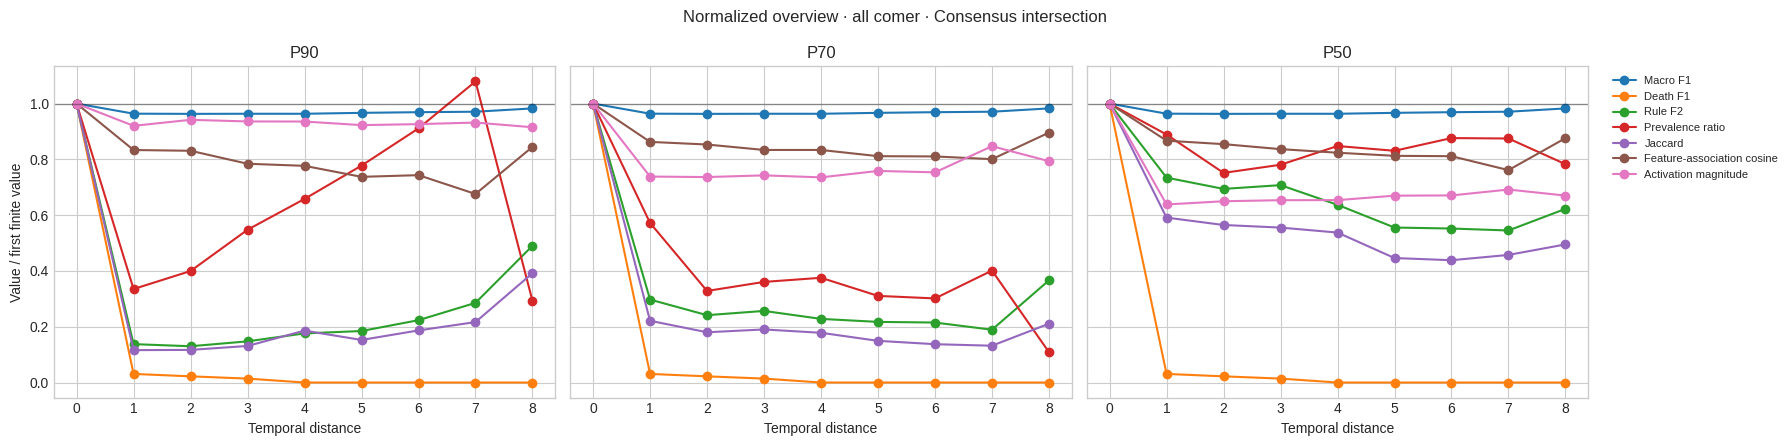

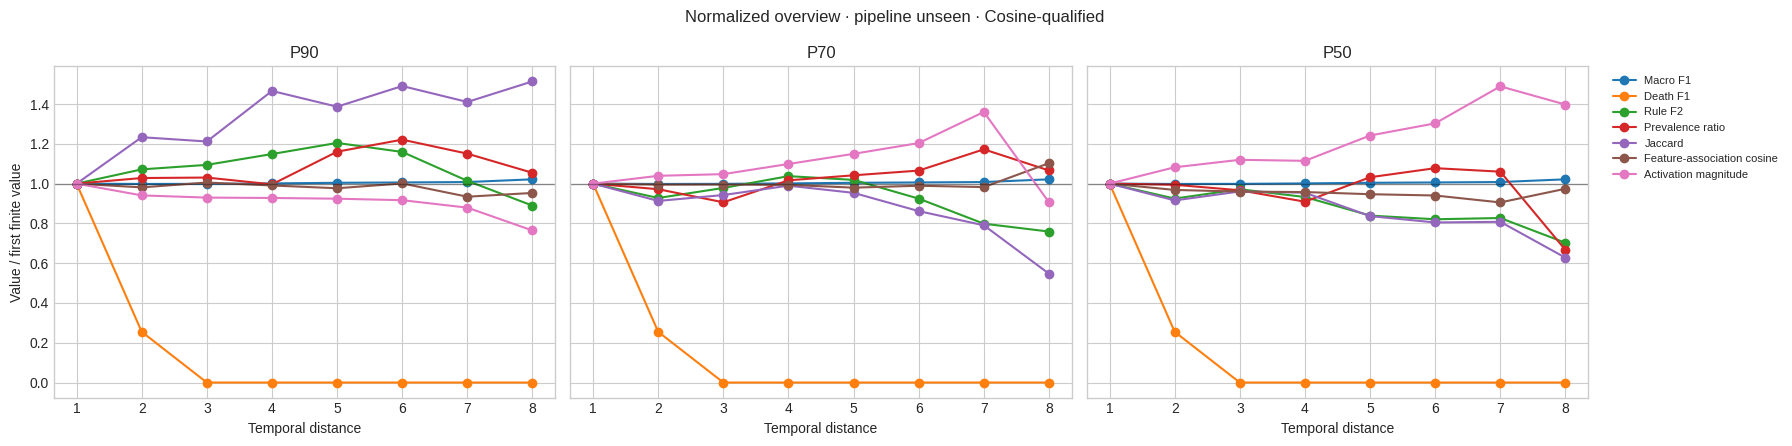

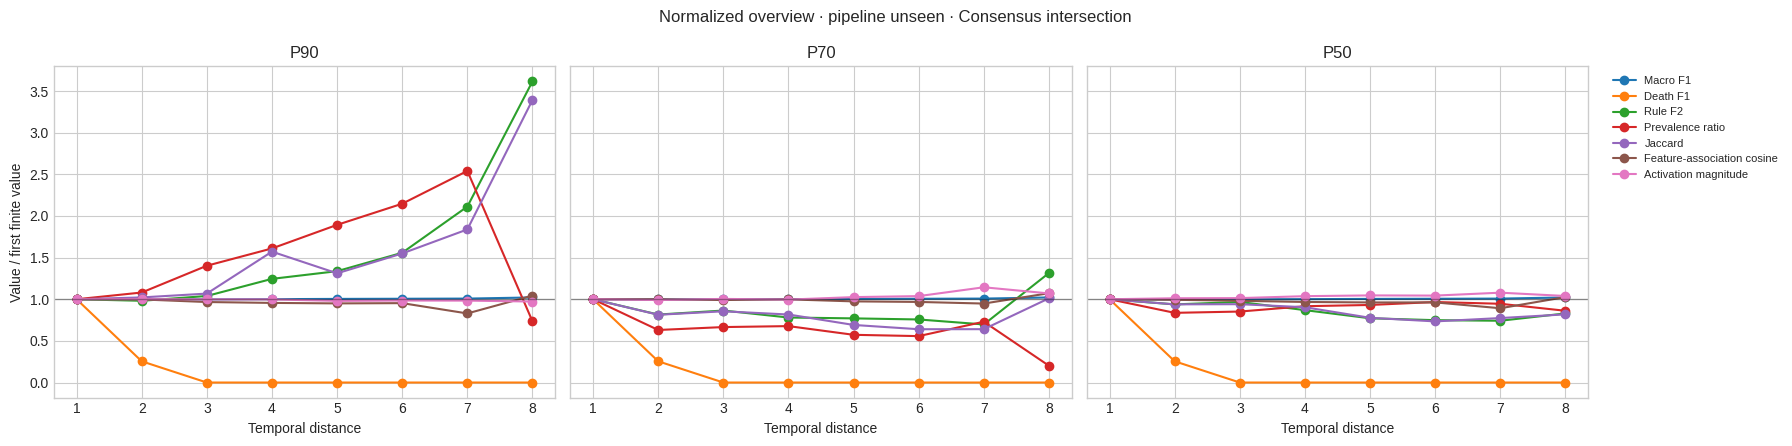

In [8]:
def normalized_curve(summary, metric, filters):
    selected = summary[summary['metric'].eq(metric)].copy()
    for field, value in filters.items(): selected = selected[selected[field].eq(value)]
    rows = normalize_first_finite(selected.to_dict('records'), metric='mean', group_fields=tuple(filters))
    return pd.DataFrame(rows)

normalized_metrics = [('macro_f1', 'Macro F1'), ('death_f1', 'Death F1'), ('f2', 'Rule F2'), ('prevalence_ratio', 'Prevalence ratio'), ('jaccard', 'Jaccard'), ('feature_association_cosine', 'Feature-association cosine'), ('activation_magnitude_ratio', 'Activation magnitude')]
for cohort in COHORTS:
    for view in ('cosine_qualified', 'intersection'):
        fig, axes = plt.subplots(1, len(ACTIVATION_TARGETS), figsize=(18, 4.5), sharey=True)
        for axis, target in zip(axes, ACTIVATION_TARGETS):
            for metric, label in normalized_metrics:
                if metric in {'macro_f1', 'death_f1'}:
                    curve = normalized_curve(performance_summary, metric, {'cohort_view': cohort})
                else:
                    curve = normalized_curve(factor_summary, metric, {'cohort_view': cohort, 'matching_view': view, 'rule_source': 'semantic', 'activation_target': target})
                if not curve.empty: axis.plot(curve['temporal_distance'], curve['normalized_value'], marker='o', label=label)
            axis.axhline(1, color='black', linewidth=1, alpha=.35)
            axis.set(title=TARGET_LABEL[target], xlabel='Temporal distance')
        axes[0].set_ylabel('Value / first finite value')
        axes[-1].legend(bbox_to_anchor=(1.03, 1), loc='upper left', fontsize=8)
        fig.suptitle(f"Normalized overview · {cohort.replace('_', ' ')} · {VIEW_LABEL[view]}")
        fig.tight_layout(); plt.show()

In [ ]:
tcav_factor_columns = [
    'reference_year', 'patient_split_seed', 'factor_family_uid',
    'member_sae_seed', 'member_factor_id', 'activation_percentile',
    'activation_target', 'rule_source', 'target_role', 'cohort_view',
    'test_year', 'temporal_distance', 'matching_views', 'tcav',
    'tcav_std', 'repetition_count', 'p_value', 'q_value', 'tcav_valid',
]
if tcav_all.empty:
    tcav_factor_table = pd.DataFrame(columns=tcav_factor_columns)
else:
    tcav_factor_table = tcav_all.copy()
    factor_result_keys = [
        'reference_year', 'patient_split_seed', 'factor_family_uid',
        'member_sae_seed', 'member_factor_id', 'activation_target',
        'rule_source', 'target_role', 'cohort_view', 'test_year',
        'temporal_distance',
    ]
    matching_membership = (tcav_factor_table
        .groupby(factor_result_keys, dropna=False)['matching_view']
        .agg(lambda values: ', '.join(sorted(set(values.dropna().astype(str)))))
        .rename('matching_views').reset_index())
    tcav_factor_table = (tcav_factor_table
        .drop(columns=['matching_view'], errors='ignore')
        .drop_duplicates(subset=factor_result_keys)
        .merge(matching_membership, on=factor_result_keys, how='left'))
    tcav_factor_table['activation_percentile'] = tcav_factor_table['activation_target'].map(TARGET_LABEL)
    tcav_factor_table = tcav_factor_table[tcav_factor_columns].sort_values(
        ['cohort_view', 'activation_target', 'reference_year',
         'patient_split_seed', 'factor_family_uid', 'member_sae_seed',
         'member_factor_id', 'temporal_distance'],
        na_position='last',
    ).reset_index(drop=True)
display(tcav_factor_table[(tcav_factor_table['tcav'] != 0) & (tcav_factor_table['tcav'] != 1)])

,reference_year,patient_split_seed,factor_family_uid,member_sae_seed,member_factor_id,activation_percentile,activation_target,rule_source,target_role,cohort_view,test_year,temporal_distance,matching_views,tcav,tcav_std,repetition_count,p_value,q_value,tcav_valid
85,2015,43,2015/43/42/247,42,247,P50,0.5,semantic,secondary,all_comer,2015,0,"cosine_qualified, intersection",0.030093,0.116548,15,0.039092,0.039092,True


### Reference-year matrices and post-hoc temporal categories

Triangular matrices retain the reference-year estimand. Temporal categories are displayed only as outcomes and never used to select families.

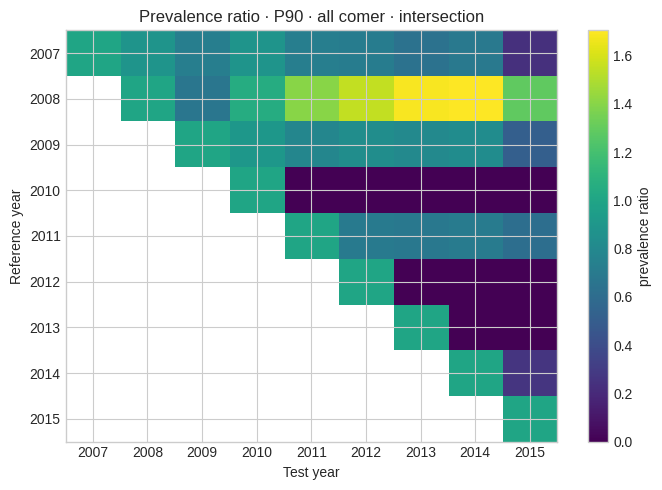

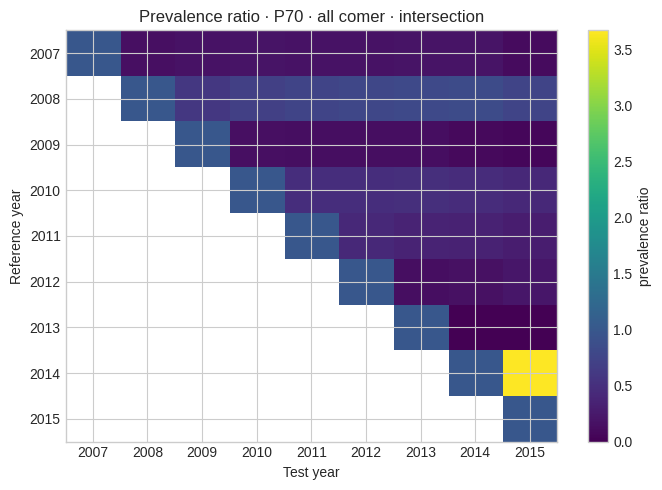

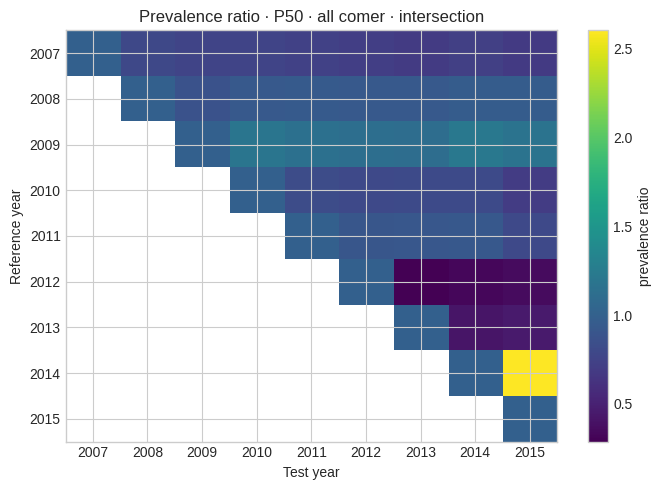

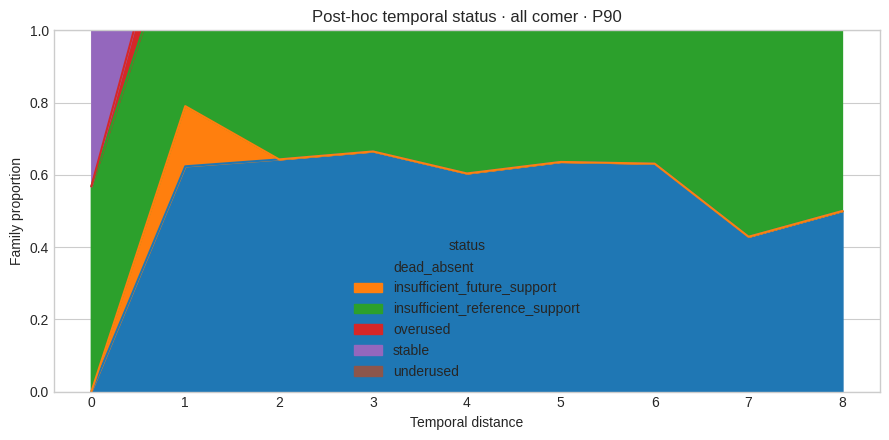

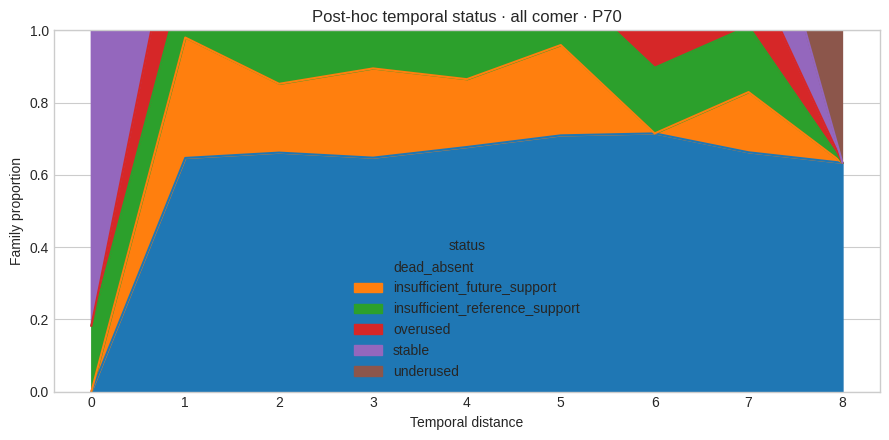

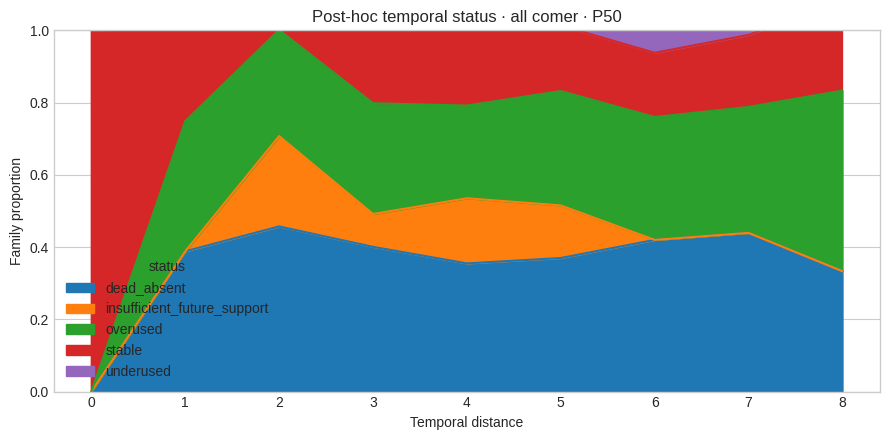

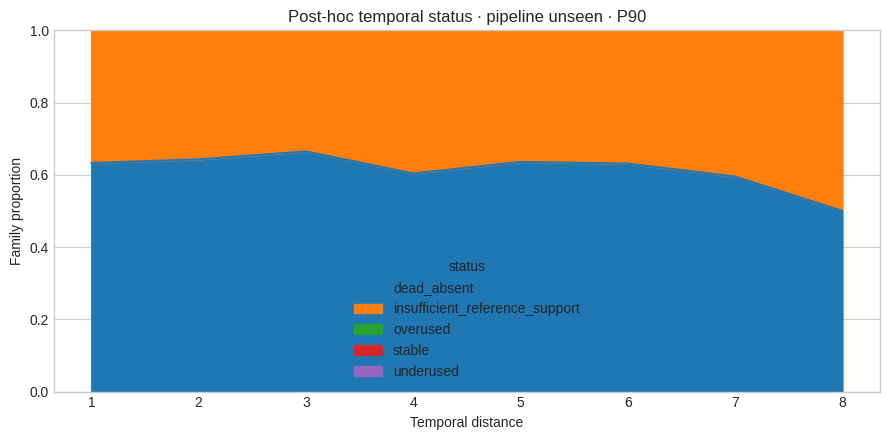

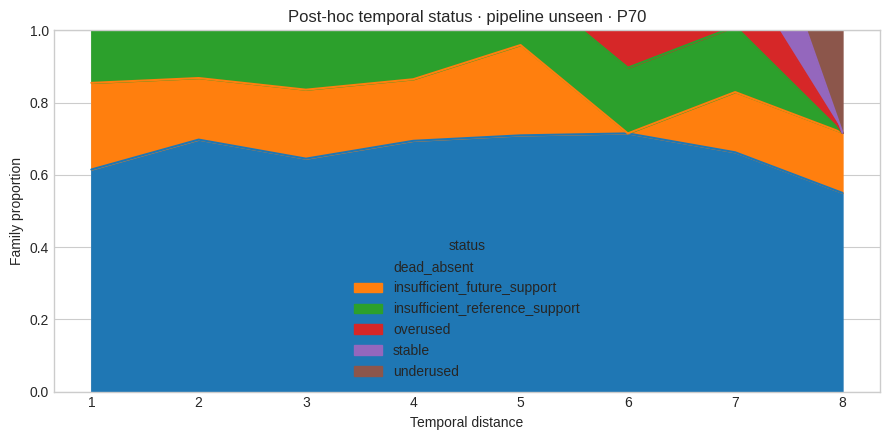

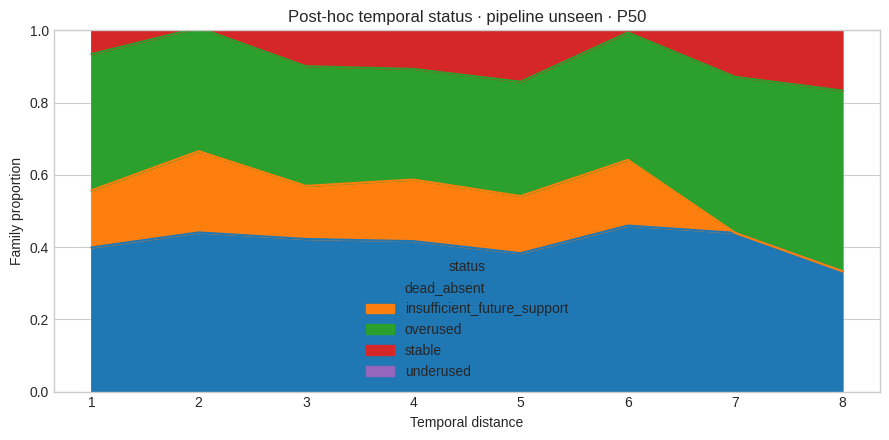

In [10]:
def triangular_heatmap(frame, metric, title, filters):
    selected = frame.copy()
    for field, value in filters.items(): selected = selected[selected[field].eq(value)]
    matrix = selected.pivot_table(index='reference_year', columns='test_year', values=metric, aggfunc='mean')
    if matrix.empty: return
    fig, ax = plt.subplots(figsize=(7, 5))
    image = ax.imshow(matrix, aspect='auto', cmap='viridis')
    ax.set(xticks=range(len(matrix.columns)), xticklabels=matrix.columns, yticks=range(len(matrix.index)), yticklabels=matrix.index, xlabel='Test year', ylabel='Reference year', title=title)
    fig.colorbar(image, ax=ax, label=metric.replace('_', ' ')); fig.tight_layout(); plt.show()

for target in ACTIVATION_TARGETS:
    triangular_heatmap(factors, 'prevalence_ratio', f"Prevalence ratio · {TARGET_LABEL[target]} · all comer · intersection", {'cohort_view': 'all_comer', 'matching_view': 'intersection', 'rule_source': 'semantic', 'activation_target': target})

for cohort in COHORTS:
    for target in ACTIVATION_TARGETS:
        selected = status[(status['cohort_view'].eq(cohort)) & (status['matching_view'].eq('intersection')) & (status['rule_source'].eq('semantic')) & (status['activation_target'].eq(target))]
        composition = selected.groupby(['temporal_distance', 'status'], as_index=False)['status_proportion'].mean()
        if composition.empty: continue
        pivot = composition.pivot(index='temporal_distance', columns='status', values='status_proportion').fillna(0)
        pivot.plot.area(figsize=(9, 4.5), ylim=(0, 1), title=f"Post-hoc temporal status · {cohort.replace('_', ' ')} · {TARGET_LABEL[target]}")
        plt.ylabel('Family proportion'); plt.xlabel('Temporal distance'); plt.tight_layout(); plt.show()

## 6. Quantitative temporal changes

These tables pair identical observational units before aggregation. They report adjacent and cumulative native-unit changes, paired support, improvement/deterioration fractions, 95% paired hierarchical-bootstrap intervals, and interval directionality. Prevalence and activation-magnitude ratios additionally quantify movement toward or away from 1.

In [11]:
deltas = DERIVED['paired_temporal_deltas'].copy()
evidence = DERIVED['delta_evidence'].copy()
delta_columns = ['metric', 'delta_kind', 'cohort_view', 'matching_view', 'rule_source', 'activation_target', 'status', 'from_distance', 'to_distance', 'previous_mean', 'current_mean', 'delta', 'relative_change', 'stability_deviation_change', 'paired_support', 'fraction_negative', 'fraction_positive', 'lower_95', 'upper_95', 'ci_excludes_zero']
delta_columns = [column for column in delta_columns if column in deltas]
for metric in ('macro_f1', 'death_f1', 'f2', 'prevalence_ratio', 'jaccard', 'feature_association_cosine', 'activation_magnitude_ratio', 'tcav', 'status_proportion'):
    display(Markdown(f"### {metric.replace('_', ' ').title()} deltas"))
    display(deltas[deltas['metric'].eq(metric)][delta_columns].sort_values(['cohort_view', 'activation_target', 'delta_kind', 'to_distance'], na_position='last'))
display(Markdown('### Numeric evidence summary'))
display(evidence.sort_values(['metric', 'cohort_view', 'activation_target'], na_position='last'))

### Macro F1 deltas

,metric,delta_kind,cohort_view,matching_view,rule_source,activation_target,status,from_distance,to_distance,previous_mean,current_mean,delta,relative_change,stability_deviation_change,paired_support,fraction_negative,fraction_positive,lower_95,upper_95,ci_excludes_zero
0,macro_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,0,1,0.489712,0.479880,-0.009832,-0.018378,NaN,24,0.500000,0.500000,-0.018744,-0.000929,True
1,macro_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,1,2,0.478537,0.479544,0.001007,0.002180,NaN,21,0.428571,0.571429,-0.001865,0.003708,False
2,macro_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,2,3,0.477921,0.479735,0.001814,0.003832,NaN,18,0.333333,0.666667,-0.001063,0.004797,False
3,macro_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,3,4,0.477825,0.479709,0.001884,0.003979,NaN,15,0.466667,0.533333,-0.001243,0.005046,False
4,macro_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,4,5,0.477316,0.481363,0.004048,0.008511,NaN,12,0.250000,0.750000,0.001219,0.006948,True
5,macro_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,5,6,0.478724,0.482529,0.003805,0.007983,NaN,9,0.333333,0.666667,-0.000264,0.008155,False
6,macro_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,6,7,0.479152,0.483380,0.004227,0.008878,NaN,6,0.500000,0.500000,-0.000824,0.009279,False
7,macro_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,7,8,0.477477,0.489282,0.011804,0.024722,NaN,3,0.000000,1.000000,0.011804,0.011804,True
8,macro_f1,cumulative,all_comer,NaN,NaN,NaN,NaN,0,1,0.489712,0.479880,-0.009832,-0.018378,NaN,24,0.500000,0.500000,-0.018786,-0.001800,True
9,macro_f1,cumulative,all_comer,NaN,NaN,NaN,NaN,0,2,0.491448,0.479544,-0.011904,-0.022281,NaN,21,0.714286,0.285714,-0.022776,-0.002477,True


### Death F1 deltas

,metric,delta_kind,cohort_view,matching_view,rule_source,activation_target,status,from_distance,to_distance,previous_mean,current_mean,delta,relative_change,stability_deviation_change,paired_support,fraction_negative,fraction_positive,lower_95,upper_95,ci_excludes_zero
30,death_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,0,1,0.022493,0.001121,-0.021372,-0.966368,NaN,24,0.250000,0.000000,-0.037549,-0.005952,True
31,death_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,1,2,0.001281,0.000805,-0.000476,-0.714103,NaN,21,0.047619,0.047619,-0.002745,0.001317,False
32,death_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,2,3,0.000939,0.000512,-0.000427,-0.400922,NaN,18,0.055556,0.055556,-0.001536,0.000254,False
33,death_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,3,4,0.000614,0.000000,-0.000614,-1.000000,NaN,15,0.066667,0.000000,-0.001843,0.000000,False
34,death_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,4,5,0.000000,0.000000,0.000000,NaN,NaN,12,0.000000,0.000000,0.000000,0.000000,False
35,death_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,5,6,0.000000,0.000000,0.000000,NaN,NaN,9,0.000000,0.000000,0.000000,0.000000,False
36,death_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,6,7,0.000000,0.000000,0.000000,NaN,NaN,6,0.000000,0.000000,0.000000,0.000000,False
37,death_f1,adjacent,all_comer,NaN,NaN,NaN,NaN,7,8,0.000000,0.000000,0.000000,NaN,NaN,3,0.000000,0.000000,0.000000,0.000000,False
38,death_f1,cumulative,all_comer,NaN,NaN,NaN,NaN,0,1,0.022493,0.001121,-0.021372,-0.966368,NaN,24,0.250000,0.000000,-0.037507,-0.007362,True
39,death_f1,cumulative,all_comer,NaN,NaN,NaN,NaN,0,2,0.025707,0.000805,-0.024901,-0.972719,NaN,21,0.285714,0.000000,-0.044490,-0.008707,True


### F2 deltas

...

,metric,delta_kind,cohort_view,matching_view,rule_source,activation_target,status,from_distance,to_distance,previous_mean,current_mean,delta,relative_change,stability_deviation_change,paired_support,fraction_negative,fraction_positive,lower_95,upper_95,ci_excludes_zero
1848,tcav,adjacent,all_comer,cosine_qualified,semantic,0.5,NaN,0,1,0.0,0.0,0.0,NaN,NaN,5,0.0,0.0,0.0,0.0,False
1860,tcav,adjacent,all_comer,intersection,semantic,0.5,NaN,0,1,0.0,0.0,0.0,NaN,NaN,5,0.0,0.0,0.0,0.0,False
1849,tcav,adjacent,all_comer,cosine_qualified,semantic,0.5,NaN,1,2,0.0,0.0,0.0,NaN,NaN,10,0.0,0.0,0.0,0.0,False
1861,tcav,adjacent,all_comer,intersection,semantic,0.5,NaN,1,2,0.0,0.0,0.0,NaN,NaN,10,0.0,0.0,0.0,0.0,False
1850,tcav,adjacent,all_comer,cosine_qualified,semantic,0.5,NaN,2,3,0.0,0.0,0.0,NaN,NaN,6,0.0,0.0,0.0,0.0,False
1862,tcav,adjacent,all_comer,intersection,semantic,0.5,NaN,2,3,0.0,0.0,0.0,NaN,NaN,6,0.0,0.0,0.0,0.0,False
1851,tcav,adjacent,all_comer,cosine_qualified,semantic,0.5,NaN,3,4,0.0,0.0,0.0,NaN,NaN,5,0.0,0.0,0.0,0.0,False
1863,tcav,adjacent,all_comer,intersection,semantic,0.5,NaN,3,4,0.0,0.0,0.0,NaN,NaN,5,0.0,0.0,0.0,0.0,False
1852,tcav,adjacent,all_comer,cosine_qualified,semantic,0.5,NaN,4,5,0.0,0.0,0.0,NaN,NaN,4,0.0,0.0,0.0,0.0,False
1864,tcav,adjacent,all_comer,intersection,semantic,0.5,NaN,4,5,0.0,0.0,0.0,NaN,NaN,4,0.0,0.0,0.0,0.0,False


### Status Proportion deltas

,metric,delta_kind,cohort_view,matching_view,rule_source,activation_target,status,from_distance,to_distance,previous_mean,current_mean,delta,relative_change,stability_deviation_change,paired_support,fraction_negative,fraction_positive,lower_95,upper_95,ci_excludes_zero
1906,status_proportion,adjacent,all_comer,cosine_qualified,high_precision,0.1,insufficient_reference_support,0,1,0.611111,0.611111,0.000000,0.000000,NaN,3,0.0,0.0,0.000000,0.000000,False
1930,status_proportion,adjacent,all_comer,cosine_qualified,high_precision,0.1,stable,0,1,1.000000,0.500000,-50.000000,-0.500000,NaN,1,1.0,0.0,-50.000000,-50.000000,True
2102,status_proportion,adjacent,all_comer,cosine_qualified,semantic,0.1,insufficient_reference_support,0,1,0.460719,0.460719,0.000000,0.000000,NaN,24,0.0,0.0,0.000000,0.000000,False
2132,status_proportion,adjacent,all_comer,cosine_qualified,semantic,0.1,stable,0,1,0.584046,0.080236,-50.381045,-0.859343,NaN,11,1.0,0.0,-59.794354,-41.117697,True
2342,status_proportion,adjacent,all_comer,intersection,high_precision,0.1,insufficient_reference_support,0,1,0.750000,0.750000,0.000000,0.000000,NaN,2,0.0,0.0,0.000000,0.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3224,status_proportion,cumulative,pipeline_unseen,intersection,high_precision,0.5,overused,1,8,0.142857,0.142857,0.000000,0.000000,NaN,1,0.0,0.0,0.000000,0.000000,False
3250,status_proportion,cumulative,pipeline_unseen,intersection,high_precision,0.5,underused,1,8,0.571429,0.571429,0.000000,0.000000,NaN,1,0.0,0.0,0.000000,0.000000,False
3388,status_proportion,cumulative,pipeline_unseen,intersection,semantic,0.5,dead_absent,1,8,0.333333,0.333333,0.000000,0.000000,NaN,1,0.0,0.0,0.000000,0.000000,False
3412,status_proportion,cumulative,pipeline_unseen,intersection,semantic,0.5,overused,1,8,0.750000,0.500000,-25.000000,-0.333333,NaN,1,1.0,0.0,-25.000000,-25.000000,True


### Numeric evidence summary

,activation_target,cohort_view,first_directional_to_distance,furthest_cumulative_change,insufficient_paired_support,largest_adjacent_deterioration,largest_adjacent_to_distance,matching_view,metric,minimum_paired_support,rule_source
0,0.1,all_comer,1.0,-0.064566,False,-0.091390,1,cosine_qualified,activation_magnitude_ratio,2,high_precision
3,0.1,all_comer,6.0,-0.249439,False,-0.029796,8,cosine_qualified,activation_magnitude_ratio,16,semantic
6,0.1,all_comer,1.0,-0.079398,False,-0.118592,1,intersection,activation_magnitude_ratio,2,high_precision
9,0.1,all_comer,1.0,-0.084746,False,-0.079679,1,intersection,activation_magnitude_ratio,4,semantic
1,0.3,all_comer,1.0,-0.210138,False,-0.224771,1,cosine_qualified,activation_magnitude_ratio,12,high_precision
...,...,...,...,...,...,...,...,...,...,...,...
147,0.5,pipeline_unseen,6.0,0.000000,True,-25.000000,8,intersection,status_proportion,1,semantic
148,0.5,all_comer,NaN,0.000000,False,0.000000,1,cosine_qualified,tcav,3,semantic
149,0.5,all_comer,NaN,0.000000,False,0.000000,1,intersection,tcav,3,semantic
150,0.5,pipeline_unseen,NaN,0.000000,False,0.000000,2,cosine_qualified,tcav,4,semantic


## 7. Relationship with model performance

The direct degradation, lead–lag, and change-point views below are exploratory associations, not causal evidence. Both sides of every association refer to the original fitted system; balanced-context sensitivity results are excluded.

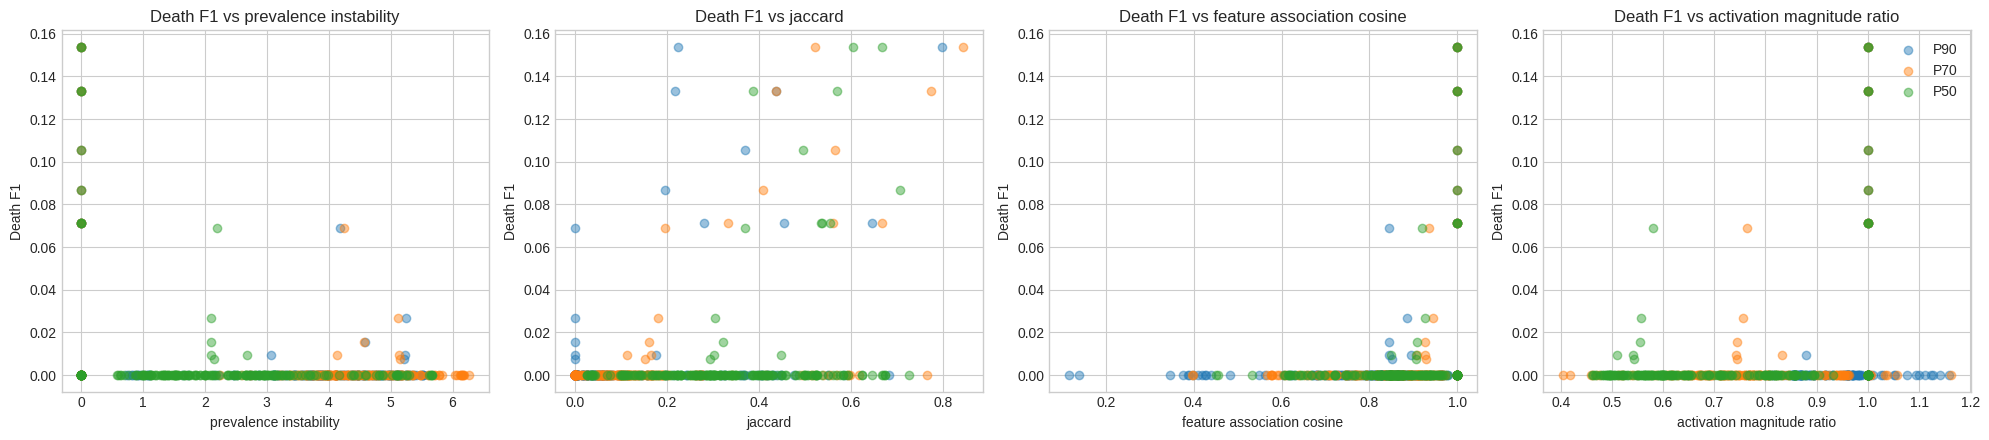

/home/rafaelgomes/SAE-TCAV/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/rafaelgomes/SAE-TCAV/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/rafaelgomes/SAE-TCAV/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/rafaelgomes/SAE-TCAV/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/rafaelgomes/SAE-TCAV/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/rafaelgomes/SAE-TCAV/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c

,cohort_view,activation_target,lag,metric,correlation,paired_rows
0,all_comer,0.1,0,prevalence_instability,-0.445637,117
1,all_comer,0.1,0,feature_association_cosine,0.306916,117
2,all_comer,0.1,1,prevalence_instability,-0.088210,93
3,all_comer,0.1,1,feature_association_cosine,0.124960,93
4,all_comer,0.1,2,prevalence_instability,-0.117175,72
5,all_comer,0.1,2,feature_association_cosine,0.171524,72
6,all_comer,0.3,0,prevalence_instability,-0.511291,114
7,all_comer,0.3,0,feature_association_cosine,0.322327,114
8,all_comer,0.3,1,prevalence_instability,-0.116015,91
9,all_comer,0.3,1,feature_association_cosine,0.145754,91


**Exploratory parent change-point diagnostics**

,bic_improvement,breakpoint,exploratory,metric,no_break_bic,reference_year,segmented_bic,segmented_preferred,sustained_crossing,valid,failure_reason
0,10.300586,2.0,True,macro_f1,-84.891452,2007,-95.192038,True,None,True,NaN
1,6.609720,3.0,True,macro_f1,-75.551872,2008,-82.161591,True,None,True,NaN
2,10.797852,2.0,True,macro_f1,-59.780414,2009,-70.578266,True,None,True,NaN
3,3.252665,2.0,True,macro_f1,-52.233793,2010,-55.486458,True,None,True,NaN
4,-1.446082,2.0,True,macro_f1,-55.140500,2011,-53.694418,False,None,True,NaN
5,NaN,NaN,NaN,macro_f1,NaN,2012,NaN,NaN,None,False,insufficient_segmented_observations
6,NaN,NaN,NaN,macro_f1,NaN,2013,NaN,NaN,None,False,insufficient_segmented_observations
7,NaN,NaN,NaN,macro_f1,NaN,2014,NaN,NaN,None,False,insufficient_segmented_observations
8,NaN,NaN,NaN,macro_f1,NaN,2015,NaN,NaN,None,False,insufficient_segmented_observations
9,10.452523,2.0,True,prevalence_ratio,13.743960,2007,3.291437,True,None,True,NaN


In [12]:
model_units = (performance.groupby(['reference_year', 'patient_split_seed', 'cohort_view', 'temporal_distance'], as_index=False)[['macro_f1', 'death_f1']].mean())
concept_units = (factors[(factors['matching_view'].eq('intersection')) & (factors['rule_source'].eq('semantic'))]
    .groupby(['reference_year', 'patient_split_seed', 'cohort_view', 'activation_target', 'temporal_distance'], as_index=False)[['f2', 'prevalence_instability', 'jaccard', 'feature_association_cosine', 'activation_magnitude_ratio']].mean())
aligned = model_units.merge(concept_units, on=['reference_year', 'patient_split_seed', 'cohort_view', 'temporal_distance'], how='inner')
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for axis, metric in zip(axes, ('prevalence_instability', 'jaccard', 'feature_association_cosine', 'activation_magnitude_ratio')):
    for target in ACTIVATION_TARGETS:
        selected = aligned[aligned['activation_target'].eq(target)]
        axis.scatter(selected[metric], selected['death_f1'], alpha=.45, label=TARGET_LABEL[target])
    axis.set(xlabel=metric.replace('_', ' '), ylabel='Death F1', title='Death F1 vs ' + metric.replace('_', ' '))
axes[-1].legend(); fig.tight_layout(); plt.show()

exploratory = []
for (cohort, target), group in aligned.groupby(['cohort_view', 'activation_target']):
    for lag in (0, 1, 2):
        shifted = group.copy()
        shifted['concept_distance'] = shifted['temporal_distance'] + lag
        paired = group[['reference_year', 'patient_split_seed', 'temporal_distance', 'death_f1']].merge(
            shifted[['reference_year', 'patient_split_seed', 'concept_distance', 'prevalence_instability', 'feature_association_cosine']],
            left_on=['reference_year', 'patient_split_seed', 'temporal_distance'], right_on=['reference_year', 'patient_split_seed', 'concept_distance'])
        for metric in ('prevalence_instability', 'feature_association_cosine'):
            exploratory.append({'cohort_view': cohort, 'activation_target': target, 'lag': lag, 'metric': metric, 'correlation': paired['death_f1'].corr(paired[metric]), 'paired_rows': len(paired)})
display(pd.DataFrame(exploratory))
display(Markdown('**Exploratory parent change-point diagnostics**'))
display(PARENT_TABLES['change_points'])

## 8. Balanced-context sensitivity experiment

Two consecutive distances with aggregate zero original-system death F1 trigger a deterministic equal-death/survivor reference-context fit. That re-contextualized model is a separate sensitivity experiment only: it never replaces the original-system performance in headline plots, temporal deltas, concept–performance associations, or CRI analyses. The table and plots below compare systems explicitly and must not be interpreted as a threshold-only sensitivity analysis.

,balanced_context_count,balanced_context_deaths,balanced_context_survivors,balanced_sensitivity_available,balanced_sensitivity_row_count,cohort_view,fallback_triggered,primary_variant,selected_row_count,selected_variant,sensitivity_triggered,sensitivity_variant,trigger_distance_pairs
0,"[98, 142, 180, 190, 214, 216, 220, 226, 258]","[49, 71, 90, 95, 107, 108, 110, 113, 129]","[49, 71, 90, 95, 107, 108, 110, 113, 129]",True,135,all_comer,False,original,135,original,True,balanced_context,"[[4, 5], [5, 6], [6, 7], [7, 8]]"
1,"[142, 180, 190, 214, 216, 220, 226, 258]","[71, 90, 95, 107, 108, 110, 113, 129]","[71, 90, 95, 107, 108, 110, 113, 129]",True,108,pipeline_unseen,False,original,108,original,True,balanced_context,"[[3, 4], [4, 5], [5, 6], [6, 7], [7, 8]]"


,variant,cohort_view,temporal_distance,macro_f1,death_f1,rows,deaths,survivors
0,balanced_context,all_comer,0,0.548583,0.290952,27,651,7572
1,balanced_context,all_comer,1,0.536289,0.279298,24,4800,55407
2,balanced_context,all_comer,2,0.529169,0.271548,21,4263,48741
3,balanced_context,all_comer,3,0.529024,0.260533,18,3606,41901
4,balanced_context,all_comer,4,0.529511,0.255993,15,2958,34749
5,balanced_context,all_comer,5,0.518421,0.232090,12,2184,27945
6,balanced_context,all_comer,6,0.515955,0.221203,9,1539,20982
7,balanced_context,all_comer,7,0.491900,0.194567,6,966,13797
8,balanced_context,all_comer,8,0.494637,0.154853,3,291,6642
9,balanced_context,pipeline_unseen,1,0.445738,0.245538,24,1832,18721


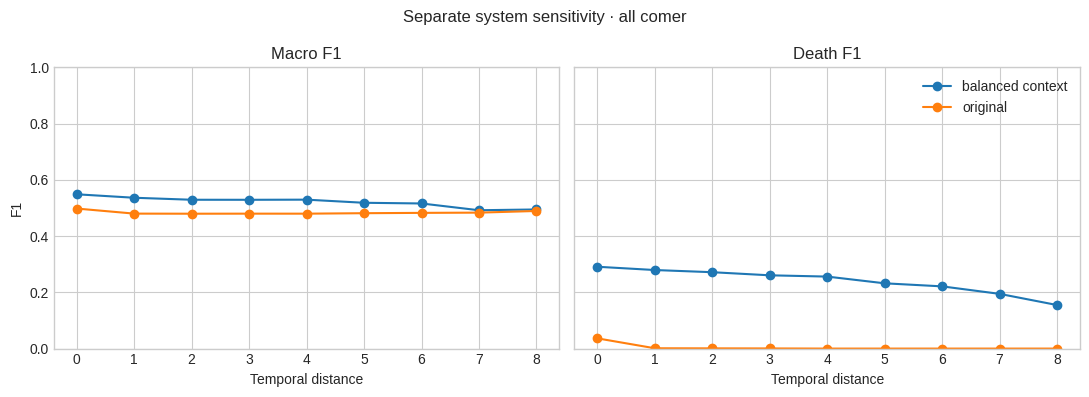

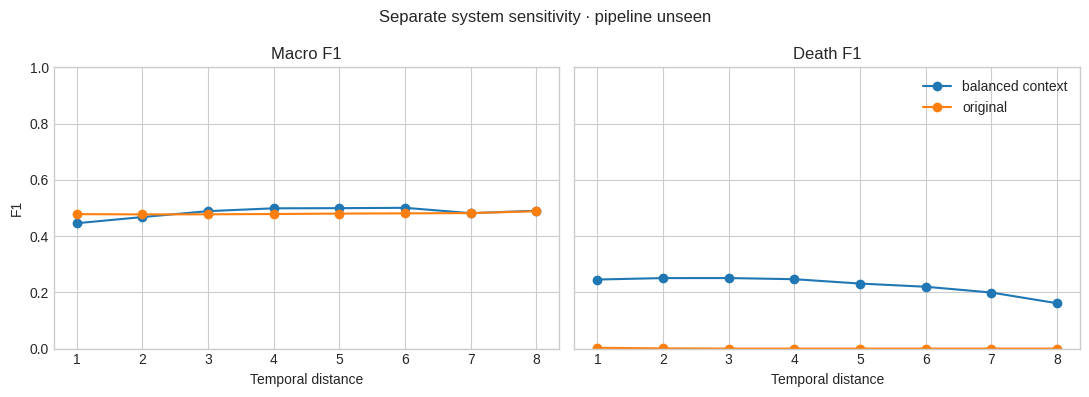

In [13]:
display(DERIVED['balanced_context_sensitivity_audit'])
variant_audit = (DERIVED['performance_variants'].groupby(['variant', 'cohort_view', 'temporal_distance'], as_index=False)
    .agg(macro_f1=('macro_f1', 'mean'), death_f1=('death_f1', 'mean'), rows=('reference_year', 'size'), deaths=('death_count', 'sum'), survivors=('survivor_count', 'sum')))
display(variant_audit)
for cohort in COHORTS:
    selected = variant_audit[variant_audit['cohort_view'].eq(cohort)]
    if selected.empty: continue
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for axis, (metric, label) in zip(axes, [('macro_f1', 'Macro F1'), ('death_f1', 'Death F1')]):
        for variant, rows in selected.groupby('variant'):
            rows = rows.sort_values('temporal_distance')
            axis.plot(rows['temporal_distance'], rows[metric], marker='o', label=variant.replace('_', ' '))
        axis.set(title=label, xlabel='Temporal distance', ylim=(0, 1))
    axes[0].set_ylabel('F1')
    axes[-1].legend()
    fig.suptitle(f"Separate system sensitivity · {cohort.replace('_', ' ')}")
    fig.tight_layout(); plt.show()

## 9. Reproducibility and invariant checks

In [14]:
assert set(factors['cohort_view'].dropna()) <= set(COHORTS)
assert set(factors['matching_view'].dropna()) <= {'cosine_qualified', 'intersection'}
assert set(np.round(factors['activation_target'].dropna().astype(float), 2)) <= set(ACTIVATION_TARGETS)
assert factors['geometric_factor_recurrence'].astype(float).gt(RECURRENCE_MIN).all()
assert ladder['matched'].le(ladder['eligible']).all()
assert ladder['recurrent'].le(ladder['matched']).all()
assert ladder['consensus'].le(ladder['recurrent']).all()
assert ladder['interpretable'].le(ladder['consensus']).all()
assert ladder['dual_source'].le(ladder['interpretable']).all()
assert not deltas['metric'].eq('tcav_normalized').any()
assert performance['selected_variant'].eq('original').all()
original_performance = DERIVED['performance_variants'][DERIVED['performance_variants']['variant'].eq('original')]
performance_identity = ['reference_year', 'patient_split_seed', 'test_year', 'temporal_distance', 'cohort_view']
performance_values = performance_identity + ['macro_f1', 'death_f1']
pd.testing.assert_frame_equal(
    performance[performance_values].sort_values(performance_identity).reset_index(drop=True),
    original_performance[performance_values].sort_values(performance_identity).reset_index(drop=True),
    check_dtype=False,
)
assert ENRICHMENT_MANIFEST['parent_hash'] == PARENT_HASH
display(pd.DataFrame({
    'invariant': ['complete parent', 'pinned identity', 'two cohorts only', 'P90/P70/P50 remain explicit', 'strict recurrence', 'nested ladder', 'actual TCAV only', 'original performance only', 'concept-performance system coupling'],
    'passed': [True] * 9,
}))
display(Markdown(f"Derived artifact manifest: `{ENRICHMENT_MANIFEST_PATH}`"))

,invariant,passed
0,complete parent,True
1,pinned identity,True
2,two cohorts only,True
3,P90/P70/P50 remain explicit,True
4,strict recurrence,True
5,nested ladder,True
6,actual TCAV only,True
7,original performance only,True
8,concept-performance system coupling,True


Derived artifact manifest: `stats/temporal_robustness/5fd57eb7b61700cda81e/derived/a3034b25b327c7484446/manifest.json`

## Conceptual Robustness Index

CRI is derived from frozen d0 semantic/intersection families. It keeps `all_comer` and `pipeline_unseen`, and P90/P70/P50, separate. Coverage is reported beside every score; missing technical support is not treated as concept collapse.

,activation_target,cohort_view,complete_family_count,coverage,fraction_below_threshold_lower,fraction_below_threshold_observed,fraction_below_threshold_upper,frozen_family_count,median_activation_utility,median_cri,median_geometric_cri,median_semantic_cohort_utility,patient_split_seed,q25_cri,reference_year,temporal_distance
34,0.1,all_comer,1,0.333333,0.000000,0.0,0.666667,3,1.000000,1.000000,1.000000,1.000000,44,1.000000,2007,0
35,0.1,all_comer,1,0.333333,0.333333,1.0,1.000000,3,0.369625,0.317338,0.086834,0.265051,44,0.317338,2007,1
36,0.1,all_comer,1,0.333333,0.333333,1.0,1.000000,3,0.402759,0.396597,0.148822,0.390434,44,0.396597,2007,2
37,0.1,all_comer,1,0.333333,0.333333,1.0,1.000000,3,0.297073,0.298626,0.130035,0.300178,44,0.298626,2007,3
38,0.1,all_comer,1,0.333333,0.333333,1.0,1.000000,3,0.300124,0.347771,0.196666,0.395419,44,0.347771,2007,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,0.5,pipeline_unseen,1,1.000000,1.000000,1.0,1.000000,1,0.000063,0.475593,0.006950,0.951122,42,0.475593,2013,2
540,0.5,pipeline_unseen,2,1.000000,1.000000,1.0,1.000000,2,0.010311,0.139933,0.012412,0.269555,43,0.069967,2013,2
549,0.5,pipeline_unseen,2,1.000000,0.500000,0.5,0.500000,2,0.000210,0.473320,0.010757,0.946430,42,0.459893,2014,1
558,0.5,pipeline_unseen,4,1.000000,1.000000,1.0,1.000000,4,0.000138,0.153265,0.000819,0.306391,43,0.113472,2014,1


,activation_target,cohort_view,mae_improvement_vs_performance_history,mae_improvement_vs_persistence,mae_macro_reference,mae_micro,model,oof_reference_count,oof_row_count,rmse_macro_reference,rmse_micro
0,0.1,all_comer,0.000000,2.436896e-04,0.000042,0.000036,performance_history,6,44,0.000046,0.000046
1,0.1,all_comer,-0.000040,2.034655e-04,0.000082,0.000094,performance_history_plus_cri,5,27,0.000132,0.000132
2,0.1,all_comer,-0.000244,0.000000e+00,0.000285,0.000508,persistence,7,59,0.002781,0.002781
3,0.3,all_comer,0.000000,7.232447e-05,0.000359,0.000496,performance_history,7,71,0.001736,0.001736
4,0.3,all_comer,-0.000074,-1.276508e-06,0.000433,0.000563,performance_history_plus_cri,7,68,0.001790,0.001790
5,0.3,all_comer,-0.000072,0.000000e+00,0.000432,0.000682,persistence,7,71,0.002970,0.002970
6,0.5,all_comer,0.000000,7.232447e-05,0.000359,0.000525,performance_history,7,67,0.001787,0.001787
7,0.5,all_comer,-0.000073,-2.607278e-07,0.000432,0.000582,performance_history_plus_cri,7,67,0.001761,0.001761
8,0.5,all_comer,-0.000072,0.000000e+00,0.000432,0.000722,persistence,7,67,0.003057,0.003057
9,0.1,pipeline_unseen,0.000000,2.136752e-04,0.000000,0.000000,performance_history,5,31,0.000000,0.000000


CRI artifact manifest: `stats/temporal_robustness/5fd57eb7b61700cda81e/derived/cri_d6d075a79151863ac633/manifest.json`

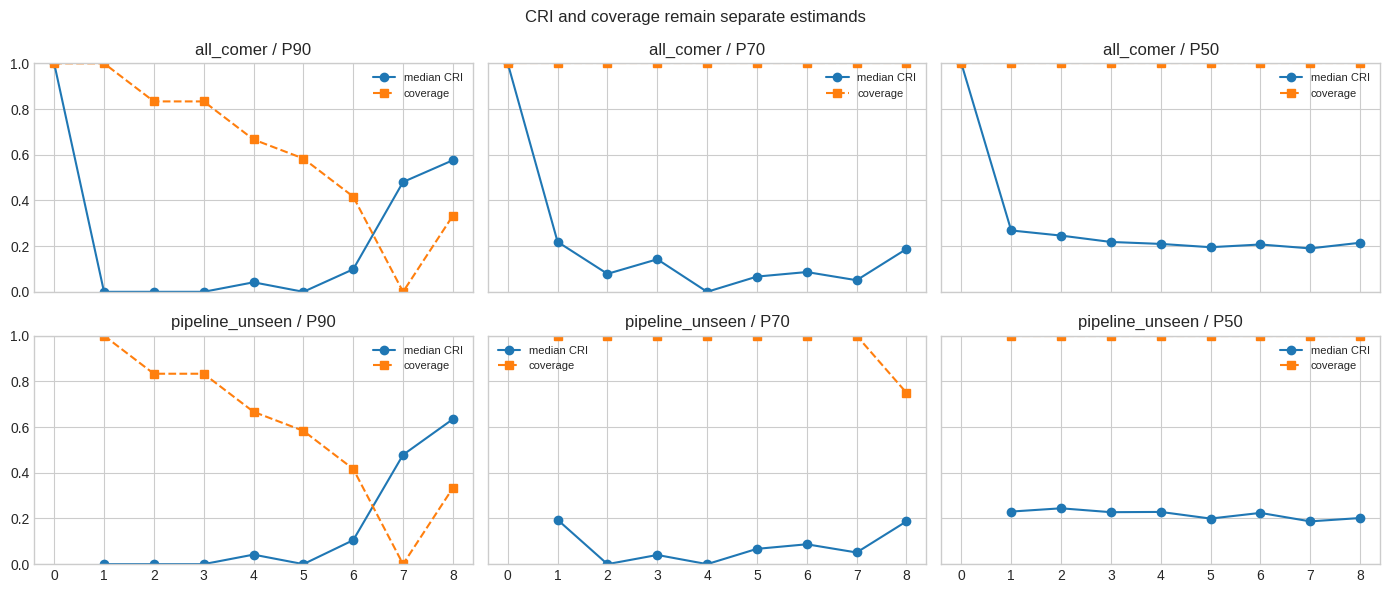

In [15]:
cri_system = CRI['cri_system_summaries'].copy()
cri_oof = CRI['cri_loyo_metrics'].copy()
display(cri_system.sort_values(['cohort_view', 'activation_target', 'reference_year', 'temporal_distance']))
display(cri_oof.sort_values(['cohort_view', 'activation_target', 'model']))

fig, axes = plt.subplots(len(COHORTS), len(ACTIVATION_TARGETS), figsize=(14, 6), sharex=True, sharey=True)
for i, cohort in enumerate(COHORTS):
    for j, target in enumerate(ACTIVATION_TARGETS):
        axis = axes[i, j]
        rows = cri_system[(cri_system.cohort_view == cohort) & (cri_system.activation_target == target)]
        summary = rows.groupby('temporal_distance', as_index=False).agg(median_cri=('median_cri', 'median'), coverage=('coverage', 'median'))
        axis.plot(summary.temporal_distance, summary.median_cri, marker='o', label='median CRI')
        axis.plot(summary.temporal_distance, summary.coverage, marker='s', linestyle='--', label='coverage')
        axis.set_title(f'{cohort} / {TARGET_LABEL[target]}')
        axis.set_ylim(0, 1); axis.legend(fontsize=8)
fig.suptitle('CRI and coverage remain separate estimands')
fig.tight_layout()
display(Markdown(f"CRI artifact manifest: `{CRI_MANIFEST_PATH}`"))

In [16]:
cri_oof

,activation_target,cohort_view,mae_improvement_vs_performance_history,mae_improvement_vs_persistence,mae_macro_reference,mae_micro,model,oof_reference_count,oof_row_count,rmse_macro_reference,rmse_micro
0,0.1,all_comer,0.000000,2.436896e-04,0.000042,0.000036,performance_history,6,44,0.000046,0.000046
1,0.1,all_comer,-0.000040,2.034655e-04,0.000082,0.000094,performance_history_plus_cri,5,27,0.000132,0.000132
2,0.1,all_comer,-0.000244,0.000000e+00,0.000285,0.000508,persistence,7,59,0.002781,0.002781
3,0.3,all_comer,0.000000,7.232447e-05,0.000359,0.000496,performance_history,7,71,0.001736,0.001736
4,0.3,all_comer,-0.000074,-1.276508e-06,0.000433,0.000563,performance_history_plus_cri,7,68,0.001790,0.001790
5,0.3,all_comer,-0.000072,0.000000e+00,0.000432,0.000682,persistence,7,71,0.002970,0.002970
6,0.5,all_comer,0.000000,7.232447e-05,0.000359,0.000525,performance_history,7,67,0.001787,0.001787
7,0.5,all_comer,-0.000073,-2.607278e-07,0.000432,0.000582,performance_history_plus_cri,7,67,0.001761,0.001761
8,0.5,all_comer,-0.000072,0.000000e+00,0.000432,0.000722,persistence,7,67,0.003057,0.003057
9,0.1,pipeline_unseen,0.000000,2.136752e-04,0.000000,0.000000,performance_history,5,31,0.000000,0.000000


## Temporal metric synthesis (derived only)

This optional downstream section reads a pinned metric-synthesis manifest. It never invokes enrichment, CRI, or any experimental runner.

In [17]:
# # Set this after running temporal_metric_synthesis.py with the pinned manifests.
# from temporal_metric_synthesis import load_metric_synthesis
# SYNTHESIS = {name: pd.DataFrame(rows) for name, rows in load_metric_synthesis(SYNTHESIS_MANIFEST).items()}
# display(SYNTHESIS['ridge_metrics_core'].query("evaluation == 'loyo'"))
# display(SYNTHESIS['pca_spectrum_core']); display(SYNTHESIS['parallel_analysis_core'])
# display(SYNTHESIS['pca_loadings_core']); display(SYNTHESIS['dae_status'])

In [22]:
import pandas as pd
from temporal_metric_synthesis import load_metric_synthesis

tables = {
    name: pd.DataFrame(rows)
    for name, rows in load_metric_synthesis(
    "stats/temporal_robustness/5fd57eb7b61700cda81e/"
    "derived/metric_synthesis_e7fed54fd004b4d530dc/manifest.json"
).items()
}

display(tables["ridge_model_comparisons_core"])
display(tables["dimension_summary_core"])
display(tables["pca_loadings_core"])
display(tables["fa_loadings_core"])
display(tables["pca_spectrum_core"])
display(tables["parallel_analysis_core"])
display(tables["metric_quality_p50_tcav_extended"])
display(tables["dimension_summary_p50_tcav_extended"])
display(tables["dae_status"])
display(tables["dae_oof_reconstruction_summary"])
display(tables["dae_latent_trajectories"])
display(tables["dae_stability"])
display(tables["runtime_telemetry"])
display(tables["ridge_metrics_core"].query("evaluation == 'loyo'"))

,analysis_population,delta_tcav_predictive_variation,evaluation,improvement_attributable_to_tcav,improvement_vs_performance_history,improvement_vs_zero_degradation,mae_macro_reference,model,profile,sensitivity_label,tcav_predictive_variation,variant
0,common_complete_case,not_applicable,loyo,False,0.000753,-0.002651,0.068671,concept_robustness,core,primary_core_analysis,not_applicable,balanced_context
1,common_complete_case,not_applicable,loyo,False,0.000147,-0.003257,0.069277,current_cri,core,primary_core_analysis,not_applicable,balanced_context
2,common_complete_case,not_applicable,loyo,False,-0.002837,-0.006241,0.072261,history_plus_concepts,core,primary_core_analysis,not_applicable,balanced_context
3,common_complete_case,not_applicable,loyo,False,0.000000,-0.003404,0.069424,performance_history,core,primary_core_analysis,not_applicable,balanced_context
4,common_complete_case,not_applicable,loyo,False,0.002497,-0.000908,0.066928,training_mean,core,primary_core_analysis,not_applicable,balanced_context
5,common_complete_case,not_applicable,loyo,False,0.003404,0.000000,0.066020,zero_degradation,core,primary_core_analysis,not_applicable,balanced_context
6,common_complete_case,not_applicable,loyo,False,-0.000224,-0.000259,0.000636,concept_robustness,core,primary_core_analysis,not_applicable,original
7,common_complete_case,not_applicable,loyo,False,-0.000216,-0.000252,0.000629,current_cri,core,primary_core_analysis,not_applicable,original
8,common_complete_case,not_applicable,loyo,False,-0.000067,-0.000102,0.000480,history_plus_concepts,core,primary_core_analysis,not_applicable,original
9,common_complete_case,not_applicable,loyo,False,0.000000,-0.000035,0.000413,performance_history,core,primary_core_analysis,not_applicable,original


,distance_zero_excluded,kaiser_retained_dimensions,parallel_retained_dimensions,profile,row_count,status
0,True,2,2,core,402,estimable


,PC1,PC2,PC3,PC4,PC5,metric,profile
0,0.922233,0.219197,-0.250303,-0.146079,-0.141215,u_f2,core
1,0.953936,0.167864,-0.188313,-0.083763,0.147794,u_jaccard,core
2,0.530097,-0.108233,0.836397,-0.100641,-0.009390,u_prevalence,core
3,0.458859,-0.670367,-0.072714,0.580608,-0.012561,u_activation,core
4,0.003144,0.857343,0.149599,0.495028,-0.003840,u_feature_association,core


,FA1,dimensions,metric,profile,FA2,FA3,FA4
0,0.956511,1,u_f2,core,NaN,NaN,NaN
1,0.995666,1,u_jaccard,core,NaN,NaN,NaN
2,0.333218,1,u_prevalence,core,NaN,NaN,NaN
3,0.283125,1,u_activation,core,NaN,NaN,NaN
4,0.076659,1,u_feature_association,core,NaN,NaN,NaN
5,0.961413,2,u_f2,core,0.051896,NaN,NaN
6,0.983343,2,u_jaccard,core,0.135837,NaN,NaN
7,0.310041,2,u_prevalence,core,0.177625,NaN,NaN
8,0.173870,2,u_activation,core,0.857443,NaN,NaN
9,0.124107,2,u_feature_association,core,-0.362862,NaN,NaN


,component,cumulative_explained_variance,eigenvalue,explained_variance_ratio,kaiser_retained,profile
0,1,0.449294,2.252072,0.449294,True,core
1,2,0.703135,1.272369,0.253841,True,core
2,3,0.867792,0.825341,0.164658,False,core
3,4,0.991612,0.620642,0.123820,False,core
4,5,1.000000,0.042045,0.008388,False,core


...

,fold_count,latent_dimensions,mae_macro_reference_seed,method,metric,mse_macro_reference_seed,profile,reference_group_count
0,24,2,0.072248,dae,overall,0.013287,core,8
1,24,2,0.132789,dae,u_f2,0.030152,core,8
2,24,2,0.108370,dae,u_jaccard,0.022178,core,8
3,24,2,0.038566,dae,u_prevalence,0.005419,core,8
4,24,2,0.052376,dae,u_activation,0.007045,core,8
5,24,2,0.029141,dae,u_feature_association,0.001643,core,8
6,24,2,0.056918,pca,overall,0.008688,core,8
7,24,2,0.085557,pca,u_f2,0.012899,core,8
8,24,2,0.064122,pca,u_jaccard,0.008372,core,8
9,24,2,0.055473,pca,u_prevalence,0.011161,core,8


,activation_target,aggregation,cohort_view,latent_1_median,latent_1_q25,latent_1_q75,latent_2_median,latent_2_q25,latent_2_q75,patient_split_seed,profile,reference_year,row_count,temporal_distance
0,0.3,system,all_comer,-0.610134,-0.619503,0.120605,-0.835871,-1.055807,-0.740692,43,core,2007,4,1
1,0.3,system,all_comer,-0.361030,-0.608091,0.476459,-1.159335,-2.504840,-0.734381,43,core,2007,4,2
2,0.3,system,all_comer,-0.606869,-0.610669,0.202368,-1.077456,-1.606700,-0.725014,43,core,2007,4,3
3,0.3,system,all_comer,-0.465267,-0.602510,0.370555,-1.156116,-2.285385,-0.710110,43,core,2007,4,4
4,0.3,system,all_comer,-0.606784,-0.607181,0.137919,-1.006598,-1.370739,-0.724464,43,core,2007,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,0.5,system,pipeline_unseen,-0.075694,-0.106510,0.211189,-0.971040,-1.223631,-0.622210,43,core,2014,3,1
431,0.1,system,all_comer,-0.505554,-0.573404,-0.437704,-2.150354,-2.662949,-1.637760,44,core,2014,2,1
432,0.5,system,all_comer,1.302604,1.298335,1.306873,0.018145,0.000761,0.035529,44,core,2014,2,1
433,0.1,system,pipeline_unseen,-0.465633,-0.550730,-0.380536,-2.309519,-2.857496,-1.761541,44,core,2014,2,1


,aligned_coordinate_correlation,latent_dimensions,left_held_out_reference_year,left_seed,procrustes_rmse,profile,right_held_out_reference_year,right_seed
0,0.965296,2,2007,42,0.006055,core,2007,43
1,0.835328,2,2007,42,0.012482,core,2007,44
2,0.987054,2,2007,42,0.003275,core,2008,42
3,0.988601,2,2007,42,0.004625,core,2008,43
4,0.870625,2,2007,42,0.010302,core,2008,44
...,...,...,...,...,...,...,...,...
271,0.853247,2,2013,44,0.011009,core,2014,43
272,0.999319,2,2013,44,0.000826,core,2014,44
273,0.975803,2,2014,42,0.005583,core,2014,43
274,0.845289,2,2014,42,0.011266,core,2014,44


,device,executor,selection_reason,stage,workers,duration_seconds,peak_cuda_memory_bytes
0,cuda,thread,automatic_resource_resolution,executor_selection,28.0,NaN,NaN
1,NaN,NaN,NaN,analysis_complete,NaN,9315.397407,82856448.0


,analysis_population,evaluation,mae_macro_reference,mae_micro,model,oof_reference_count,oof_row_count,profile,rmse_micro,target_variance,variant,zero_target_fraction
0,common_complete_case,loyo,0.068671,0.063783,concept_robustness,7,265,core,0.070595,0.004491,balanced_context,0.007547
1,common_complete_case,loyo,0.069277,0.063719,current_cri,7,265,core,0.070575,0.004491,balanced_context,0.007547
2,common_complete_case,loyo,0.072261,0.064052,history_plus_concepts,7,265,core,0.070986,0.004491,balanced_context,0.007547
3,common_complete_case,loyo,0.069424,0.063523,performance_history,7,265,core,0.070312,0.004491,balanced_context,0.007547
4,common_complete_case,loyo,0.066928,0.063328,training_mean,7,265,core,0.070085,0.004491,balanced_context,0.007547
5,common_complete_case,loyo,0.066020,0.054200,zero_degradation,7,265,core,0.077012,0.004491,balanced_context,0.007547
6,common_complete_case,loyo,0.000636,0.000868,concept_robustness,7,265,core,0.003034,0.000009,original,0.939623
7,common_complete_case,loyo,0.000629,0.000864,current_cri,7,265,core,0.003033,0.000009,original,0.939623
8,common_complete_case,loyo,0.000480,0.000704,history_plus_concepts,7,265,core,0.002840,0.000009,original,0.939623
9,common_complete_case,loyo,0.000413,0.000666,performance_history,7,265,core,0.002843,0.000009,original,0.939623
